# Глава 3. Эмпирические результаты — расчёты

Ноутбук построен так, чтобы его структура повторяла структуру главы 3 курсовой работы.
Каждый содержательный шаг оформлен по схеме: **markdown-описание (что делаем и связь с главой 2) → код → итог**.

---

## 0. Подготовка проекта

Технический раздел: окружение, конфигурация, загрузка и подготовка данных, служебные функции.
Содержательные результаты для текста курсовой начинаются с раздела 3.1.

### Запуск ноутбука

Ноутбук по умолчанию запускается без подключения Google Drive:

`USE_GOOGLE_DRIVE = False`

После запуска первой ячейки автоматически создаётся папка `/content/SPY_clustering_project/data`. **Данные надо загрузить в локальную папку data после запуска 1ой ячейки(она создаст локально папки)**

#### ВАЖНО: для воспроизводимого результата запускать с чистого состояния:
#### Runtime -> Restart session, затем Runtime -> Run all.
#### Запуск ячеек вразнобой поверх старой памяти может дать смешанное состояние.

### 0.1 Импорты и структура папок

Cоздаём структуру папок проекта `figures/`, `tables/`, `metrics/`

In [1]:
# Инструкция для воспроизведения:
# 1. Залить SPY_raw_yahoo_2005_2025.csv в /content/data/ (перетащить в файловый менеджер слева).
# 2. Runtime → Run all.
# 3. Drive подключать не нужно — все результаты создаются локально в /content/.

from pathlib import Path
import pandas as pd
import numpy as np

# ============ ПУТИ ПРОЕКТА ============
# Переключатель режима:
#   True  — рабочий режим автора (результаты сохраняются на Google Drive).
#   False — режим воспроизведения (всё локально в Colab, Drive не подключается).
#           Для проверки/научного руководителя ставить False.
USE_GOOGLE_DRIVE = False

# --- ВХОД: локальная папка данных в Colab ---
# Сюда нужно залить SPY_raw_yahoo_2005_2025.csv (перетащить в файловый менеджер Colab слева)
DATA_DIR = Path('/content/data')
DATA_DIR.mkdir(parents=True, exist_ok=True)

# --- ВЫХОД: папки результатов ---
if USE_GOOGLE_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_DIR = Path('/content/drive/MyDrive/SPY_clustering_project')
else:
    BASE_DIR = Path('/content/SPY_clustering_project')   # локально, исчезнет при Restart

FIG_DIR = BASE_DIR / 'figures'
TABLE_DIR = BASE_DIR / 'tables'
METRICS_DIR = BASE_DIR / 'metrics'

for folder in [FIG_DIR, TABLE_DIR, METRICS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("режим:", "Google Drive (автор)" if USE_GOOGLE_DRIVE else "локальный (воспроизведение)")
print("ВХОД (данные):", DATA_DIR)
print("ВЫХОД (результаты):")
print("  figures:", FIG_DIR)
print("  tables:", TABLE_DIR)
print("  metrics:", METRICS_DIR)
if not USE_GOOGLE_DRIVE:
    print("(В локальном режиме папка результатов создаётся в /content/ и очистится при Restart session.)")
print("\n>>> Залей SPY_raw_yahoo_2005_2025.csv в", DATA_DIR, "перед запуском <<<")

режим: локальный (воспроизведение)
ВХОД (данные): /content/data
ВЫХОД (результаты):
  figures: /content/SPY_clustering_project/figures
  tables: /content/SPY_clustering_project/tables
  metrics: /content/SPY_clustering_project/metrics
(В локальном режиме папка результатов создаётся в /content/ и очистится при Restart session.)

>>> Залей SPY_raw_yahoo_2005_2025.csv в /content/data перед запуском <<<


**Итог:** Папки результатов созданы на Google Drive; данные читаются из локальной /content/data

### 0.2 Конфигурация эксперимента

Единый словарь `CONFIG` со всеми параметрами протокола из главы 2: сетки подбираемых параметров (`m, tau, k, h`), окна walk-forward (`train=1260, val=252, hold=63, step=63`), фиксированные параметры (`cost_per_side=5 bps`, `n_min=30`, порог `|t_hat|>=1.0`, `n_init=10`) и `random_state=42` для воспроизводимости k-means++. Держать всё в одном месте

In [2]:
CONFIG = {
    "ticker": "SPY",
    "start_date": "2005-01-01",
    "end_date": "2026-01-01",

    "m_grid": [3, 4, 5, 6, 7, 8],
    "tau_grid": [1, 2, 3, 5],
    "k_grid": [4, 6, 8, 10, 12],
    "h_grid": [1, 5, 10, 20],

    "train_window": 1260,
    "validation_window": 252,
    "holdout_window": 63,
    "step": 63,

    "cost_per_side": 0.0005,
    "n_min": 30,
    "t_stat_threshold": 1.0,
    "n_init": 10,
    "random_state": 42,
    "use_saved_data": True,   # True — грузить зафиксированный csv (воспроизводимо); False — качать свежее с Yahoo, НО ТОГДА поменяются все итоги)))
    # т.к яху обновляет данные каждую секунду(коррективрока цен)
}

CONFIG

{'ticker': 'SPY',
 'start_date': '2005-01-01',
 'end_date': '2026-01-01',
 'm_grid': [3, 4, 5, 6, 7, 8],
 'tau_grid': [1, 2, 3, 5],
 'k_grid': [4, 6, 8, 10, 12],
 'h_grid': [1, 5, 10, 20],
 'train_window': 1260,
 'validation_window': 252,
 'holdout_window': 63,
 'step': 63,
 'cost_per_side': 0.0005,
 'n_min': 30,
 't_stat_threshold': 1.0,
 'n_init': 10,
 'random_state': 42,
 'use_saved_data': True}

**Итог:** Сетка: 6·4·5·4 = **480 кандидатных конфигураций**, но k-means обучается только 6·4·5 = **120 раз на walk** (h не влияет на центроиды). `random_state=42` зафиксирован — расчёт повторяем. Все пороги и costs соответствуют главе 2; менять только здесь.

### 0.3 Загрузка raw-данных и валидация

Прежде чем считать что-либо, надо проверить данные на типичные дефекты выгрузки: пропуски, дубли дат, нарушение порядка дат, неположительные цены, нарушение логики OHLC (High ≥ max(O,C), Low ≤ min(O,C)). Любая аномалия останавливает расчёт с понятной ошибкой — это страховка от мусора в дальнейшем pipeline.

In [3]:
# ============ ЗАГРУЗКА ДАННЫХ ИЗ ЛОКАЛЬНОГО ФАЙЛА ============
# Данные читаются только из локального csv (никакого Yahoo) — воспроизводимость.
raw_path = DATA_DIR / "SPY_raw_yahoo_2005_2025.csv"

if not raw_path.exists():
    raise FileNotFoundError(
        f"Нет файла данных: {raw_path}\n"
        f">>> Залей SPY_raw_yahoo_2005_2025.csv в папку {DATA_DIR} "
        f"(перетащи в файловый менеджер Colab слева), затем перезапусти ячейку."
    )

raw_df = pd.read_csv(raw_path, parse_dates=["Date"]).sort_values("Date").reset_index(drop=True)
print("данные загружены из:", raw_path)
print("размер:", raw_df.shape)

# ============ ВАЛИДАЦИЯ ============
display(raw_df.head())
display(raw_df.tail())
display(raw_df.isna().sum().to_frame("n_missing"))

n_dup = raw_df["Date"].duplicated().sum()
print("дублей дат:", n_dup)
if n_dup > 0:
    raise ValueError("найдены дубли дат")

if not raw_df["Date"].is_monotonic_increasing:
    raise ValueError("даты не отсортированы")

price_cols = ["Open", "High", "Low", "Close", "Adj Close"]
if (raw_df[price_cols] <= 0).sum().sum() > 0:
    raise ValueError("есть цены <= 0")

bad_high = raw_df["High"] < raw_df[["Open", "Close"]].max(axis=1)
bad_low = raw_df["Low"] > raw_df[["Open", "Close"]].min(axis=1)
print("подозрительных High:", int(bad_high.sum()), "| Low:", int(bad_low.sum()))
if bad_high.sum() > 0 or bad_low.sum() > 0:
    raise ValueError("нарушение OHLC-логики")

print("валидация пройдена")

данные загружены из: /content/data/SPY_raw_yahoo_2005_2025.csv
размер: (5283, 9)


,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
0,2005-01-03,121.559998,121.760002,119.900002,120.300003,81.383713,55748000,0.0,0.0
1,2005-01-04,120.459999,120.540001,118.440002,118.830002,80.389275,69167600,0.0,0.0
2,2005-01-05,118.739998,119.250000,118.000000,118.010002,79.834526,65667300,0.0,0.0
3,2005-01-06,118.440002,119.150002,118.260002,118.610001,80.240456,47814700,0.0,0.0
4,2005-01-07,118.970001,119.230003,118.129997,118.440002,80.125458,55847700,0.0,0.0


,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
5278,2025-12-24,687.950012,690.830017,687.799988,690.380005,688.499695,39445600,0.0,0.0
5279,2025-12-26,690.640015,691.659973,689.270020,690.309998,688.429871,41613300,0.0,0.0
5280,2025-12-29,687.539978,689.200012,686.070007,687.849976,685.976562,62559500,0.0,0.0
5281,2025-12-30,687.450012,688.559998,686.580017,687.010010,685.138916,47160700,0.0,0.0
5282,2025-12-31,687.140015,687.359985,681.710022,681.919983,680.062744,74144800,0.0,0.0


,n_missing
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
Dividends,0
Stock Splits,0


дублей дат: 0
подозрительных High: 0 | Low: 0
валидация пройдена


**Итог:** `raw_df` загружен из локального файла и провалидирован: нет пропусков в ценах, нет дублей/разрывов дат, OHLC-логика соблюдена, цены положительные. Если ячейка прошла без `ValueError` — данные чистые, можно считать признаки.  Размер (≈5283 строки) и диапазон дат 2005–2025.

### 0.4 Подготовка цен: Adj_Factor, O_adj, r[t]

Реализация раздела **2.1.3–2.1.5** главы 2. Yahoo публикует `Adj Close`, но не `Adjusted Open`, поэтому строим приближённую скорректированную цену открытия через дневной коэффициент корректировки:

- `Adj_Factor[t] = Adj Close[t] / Close[t]` — накопленная корректировка на дивиденды и сплиты;
- `O_adj[t] = Open[t] · Adj_Factor[t]` — открытие в той же скорректированной шкале, что и `Adj Close`;
- `r[t] = ln(Adj Close[t] / Adj Close[t-1])` — основной признак (дневная log-доходность);
- `r_open_to_open_1d[t] = ln(O_adj[t] / O_adj[t-1])` — вспомогательный ряд для проверки логики исполнения.

После этого признаки, target и сделки оказываются в **единой** скорректированной системе цен. `O_adj` — сконструированная, а не наблюдаемая величина (это оговорено в тексте главы 2).

In [4]:
df = raw_df.copy()

# сортируем по дате на всякий случай
# reset_index(drop=True) сбрасывает старые индексы после сортировки
df = df.sort_values("Date").reset_index(drop=True)

# выводим первые строки исходного файла
print("исходные данные:")
display(df.head())

# считаем коэффициент корректировки
# Adj_Factor = Adj Close / Close
# он показывает, какой коэффициент нужно применить к обычным ценам,
# чтобы перевести их в скорректированную шкалу
df["Adj_Factor"] = df["Adj Close"] / df["Close"]

# строим приближенную скорректированную цену открытия
# это ключевой столбец для исполнения сделок
# формула из главы 2:
# O_adj[t] = Open[t] * Adj Close[t] / Close[t]
df["O_adj"] = df["Open"] * df["Adj_Factor"]

# дополнительно строим скорректированные High и Low
# в текущей стратегии они не обязательны,
# но могут пригодиться для проверки данных или будущих расширений
df["H_adj"] = df["High"] * df["Adj_Factor"]
df["L_adj"] = df["Low"] * df["Adj_Factor"]

# считаем дневную log-доходность по скорректированной цене закрытия
# формула совпадает с формулой из главы 2:
# r[t] = ln(C_adj[t] / C_adj[t-1])
# shift(1) сдвигает столбец Adj Close на 1 строку вниз:
# первая строка будет NaN, потому что для первого дня нет предыдущей цены
df["r"] = np.log(df["Adj Close"] / df["Adj Close"].shift(1))

# считаем open-to-open log-доходность на 1 день
# это не основной признак модели,
# но полезно для проверки логики исполнения сделок
df["r_open_to_open_1d"] = np.log(df["O_adj"] / df["O_adj"].shift(1))

# проверяем, сколько пропусков появилось после расчетов
# в r и r_open_to_open_1d должен быть один пропуск в первой строке
print("пропуски после создания новых столбцов:")
display(df.isna().sum().to_frame("n_missing"))

# проверяем, что коэффициент корректировки положительный
# если Adj_Factor <= 0, значит с ценами что-то не так
if (df["Adj_Factor"] <= 0).any():
    raise ValueError("есть неположительный Adj_Factor, надо проверить данные")

# проверяем, что скорректированные цены положительные
# отрицательных или нулевых цен быть не должно
adj_price_cols = ["O_adj", "H_adj", "L_adj", "Adj Close"]

if (df[adj_price_cols] <= 0).any().any():
    raise ValueError("есть неположительные скорректированные цены")

# выводим первые строки с ключевыми столбцами
# здесь видно, как из Open через Adj_Factor получается O_adj
print("ключевые столбцы после корректировки:")
display(
    df[["Date", "Open", "Close", "Adj Close", "Adj_Factor", "O_adj", "r"]]
    .head(10)
)

# выводим последние строки с ключевыми столбцами
# в последних датах Adj_Factor обычно ближе к 1,
# потому что после них почти нет будущих дивидендов для ретроспективной корректировки
print("последние строки после корректировки:")
display(
    df[["Date", "Open", "Close", "Adj Close", "Adj_Factor", "O_adj", "r"]]
    .tail(10)
)

# смотрим распределение Adj_Factor
# чем меньше Adj_Factor, тем сильнее исторические цены были скорректированы вниз
# для старых дат SPY Adj_Factor обычно заметно меньше 1 из-за накопленных дивидендов
print("описание Adj_Factor:")
display(df["Adj_Factor"].describe().to_frame("value"))

# показываем даты, где корректировка самая сильная
# самая сильная корректировка соответствует самым маленьким значениям Adj_Factor
print("даты с самой сильной корректировкой:")
display(
    df[["Date", "Open", "Close", "Adj Close", "Adj_Factor", "O_adj"]]
    .sort_values("Adj_Factor", ascending=True)
    .head(10)
)

исходные данные:


,Date,Open,High,Low,Close,Adj Close,Volume,Dividends,Stock Splits
0,2005-01-03,121.559998,121.760002,119.900002,120.300003,81.383713,55748000,0.0,0.0
1,2005-01-04,120.459999,120.540001,118.440002,118.830002,80.389275,69167600,0.0,0.0
2,2005-01-05,118.739998,119.250000,118.000000,118.010002,79.834526,65667300,0.0,0.0
3,2005-01-06,118.440002,119.150002,118.260002,118.610001,80.240456,47814700,0.0,0.0
4,2005-01-07,118.970001,119.230003,118.129997,118.440002,80.125458,55847700,0.0,0.0


пропуски после создания новых столбцов:


,n_missing
Date,0
Open,0
High,0
Low,0
Close,0
Adj Close,0
Volume,0
Dividends,0
Stock Splits,0
Adj_Factor,0


ключевые столбцы после корректировки:


...

,Date,Open,Close,Adj Close,Adj_Factor,O_adj,r
5273,2025-12-17,679.890015,671.400024,667.598694,0.994338,676.040615,-0.011065
5274,2025-12-18,677.599976,676.469971,672.639954,0.994338,673.763561,0.007523
5275,2025-12-19,676.590027,680.590027,678.736389,0.997276,674.747283,0.009023
5276,2025-12-22,683.940002,684.830017,682.964844,0.997276,682.077253,0.006211
5277,2025-12-23,683.919983,687.960022,686.086304,0.997276,682.057268,0.004560
5278,2025-12-24,687.950012,690.380005,688.499695,0.997276,686.076320,0.003511
5279,2025-12-26,690.640015,690.309998,688.429871,0.997276,688.758989,-0.000101
5280,2025-12-29,687.539978,687.849976,685.976562,0.997276,685.667409,-0.003570
5281,2025-12-30,687.450012,687.010010,685.138916,0.997276,685.577720,-0.001222
5282,2025-12-31,687.140015,681.919983,680.062744,0.997276,685.268559,-0.007437


описание Adj_Factor:


,value
count,5283.000000
mean,0.835924
std,0.097337
min,0.676506
25%,0.751306
50%,0.835884
75%,0.926982
max,0.997276


даты с самой сильной корректировкой:


,Date,Open,Close,Adj Close,Adj_Factor,O_adj
26,2005-02-09,120.419998,119.309998,80.713943,0.676506,81.464866
36,2005-02-24,119.239998,120.239998,81.343109,0.676506,80.666603
22,2005-02-03,119.059998,118.959999,80.477188,0.676506,80.544838
40,2005-03-02,120.760002,121.169998,81.972267,0.676506,81.694902
39,2005-03-01,120.820000,121.230003,82.012863,0.676506,81.735493
19,2005-01-31,117.949997,118.160004,79.935989,0.676506,79.793919
51,2005-03-17,119.309998,119.360001,80.747795,0.676506,80.713968
0,2005-01-03,121.559998,120.300003,81.383713,0.676506,82.236107
38,2005-02-28,121.150002,120.629997,81.606956,0.676506,81.958743
28,2005-02-11,119.699997,120.769997,81.701668,0.676506,80.977806


**Итог:** Добавлены столбцы `Adj_Factor`, `O_adj`, `H_adj`, `L_adj`, `r`, `r_open_to_open_1d` к `df` (из проверенного `raw_df`). Первая строка `r`/`r_open_to_open_1d` = NaN (нет предыдущего дня) — норма, дропнем при расчёте N. `Adj_Factor` для старых дат заметно < 1 (накопленные дивиденды), к концу выборки → ближе к 1.

#### 0.4.1 Число наблюдений N и первичная статистика

После подготовки данных фиксируем `N` как длину ряда log-доходностей `r[t]` после удаления первого `NaN`. Именно `N`, а не число ценовых строк, дальше используется для расчёта числа walk-окон в разделе 3.1.

В этом же блоке считаем первичную статистику доходностей: `mean`, `std`, `skew`, `excess kurtosis`, тест Jarque-Bera, ADF-тесты для `log(C_adj)` и `r`, а также автокорреляции `ACF(r)` и `ACF(|r|)` на лагах 1, 5 и 20.

Эти показатели нужны для описания исходного ряда в Таблице 2.1 и разделе 2.1.6: они показывают отклонение доходностей от нормальности, различие между нестационарным уровнем цен и более стабильным рядом доходностей, а также наличие зависимости в абсолютных доходностях. В подборе параметров модели эти статистики не участвуют.

Подготовленный `df` остаётся в памяти и дальше используется напрямую: в нём уже есть `r`, `O_adj` и `r_oo`.

In [5]:
from scipy import stats
from statsmodels.tsa.stattools import adfuller, acf

# ряд доходностей без NaN
r_series = df["r"].dropna().to_numpy()
log_price = np.log(df["Adj Close"].to_numpy())   # уровень цен в логарифмах

# --- базовые моменты (первые 5 строк таблицы) ---
N = len(r_series)
r_mean = np.mean(r_series)
r_std = np.std(r_series, ddof=1)
r_skew = stats.skew(r_series)
r_exkurt = stats.kurtosis(r_series, fisher=True)   # excess (Fisher): нормаль -> 0

# --- Jarque-Bera (тест нормальности) ---
jb_stat, jb_pval = stats.jarque_bera(r_series)

# --- ADF на уровне цен log(C_adj): ожидаем НЕстационарность (высокий p-value) ---
adf_price_stat, adf_price_pval = adfuller(log_price, autolag="AIC")[:2]

# --- ADF на доходностях r: ожидаем стационарность (низкий p-value) ---
adf_r_stat, adf_r_pval = adfuller(r_series, autolag="AIC")[:2]

# --- ACF(r) и ACF(|r|) на лагах 1, 5, 20 ---
# acf возвращает массив [лаг0, лаг1, ..., лагN]; берём нужные лаги
acf_r = acf(r_series, nlags=20, fft=True)
acf_abs = acf(np.abs(r_series), nlags=20, fft=True)

# собираем таблицу 2.1
table_2_1 = pd.DataFrame({
    "показатель": [
        "Число наблюдений N",
        "Среднее r_mean",
        "Стандартное отклонение sigma",
        "Skewness",
        "Excess kurtosis",
        "Jarque-Bera статистика",
        "Jarque-Bera p-value",
        "ADF log(C_adj) статистика",
        "ADF log(C_adj) p-value",
        "ADF r[t] статистика",
        "ADF r[t] p-value",
        "ACF(r), лаг 1",
        "ACF(r), лаг 5",
        "ACF(r), лаг 20",
        "ACF(|r|), лаг 1",
        "ACF(|r|), лаг 5",
        "ACF(|r|), лаг 20",
    ],
    "значение": [
        N,
        round(r_mean, 6),
        round(r_std, 6),
        round(r_skew, 6),
        round(r_exkurt, 6),
        round(jb_stat, 2),
        f"{jb_pval:.2e}",
        round(adf_price_stat, 4),
        f"{adf_price_pval:.4f}",
        round(adf_r_stat, 4),
        f"{adf_r_pval:.2e}",
        round(acf_r[1], 4),
        round(acf_r[5], 4),
        round(acf_r[20], 4),
        round(acf_abs[1], 4),
        round(acf_abs[5], 4),
        round(acf_abs[20], 4),
    ],
})

# сохраняем на Drive (в tables)
table_2_1.to_csv(TABLE_DIR / "table_2_1_descriptive.csv", index=False)
display(table_2_1)

,показатель,значение
0,Число наблюдений N,5282
1,Среднее r_mean,0.000402
2,Стандартное отклонение sigma,0.012012
3,Skewness,-0.30478
4,Excess kurtosis,14.694483
5,Jarque-Bera статистика,47603.89
6,Jarque-Bera p-value,0.00e+00
7,ADF log(C_adj) статистика,0.5664
8,ADF log(C_adj) p-value,0.9868
9,ADF r[t] статистика,-18.4571


**Итог.** Описательная статистика ряда подтверждает все три свойства, заявленные в разделе 2.1.6, и согласуется со стилизованными фактами из главы 1.

- **Отклонение от нормальности.** Excess kurtosis = 14.69 (против 0 у нормального распределения) — выраженные толстые хвосты; skewness = −0.305 — лёгкая левая асимметрия (крупные падения чаще крупных ростов). Jarque-Bera = 47604 при p-value ≈ 0 — гипотеза нормальности отвергается с огромным запасом. Доходности SPY заведомо не гауссовы.
- **Нестационарность уровня против стационарности доходностей.** ADF на log(C_adj): статистика +0.57, p-value 0.987 — нестационарность не отвергается (уровень цен имеет тренд, как и ожидалось). ADF на r[t]: статистика −18.46, p-value 2·10⁻³⁰ — стационарность принимается уверенно. Это эмпирически обосновывает выбор log-доходностей как объекта моделирования.
- **Кластеризация волатильности.** ACF(r) на лагах 1/5/20: −0.103 / −0.012 / 0.023 — линейная автокорреляция самих доходностей слабая, быстро исчезает (рынок близок к мартингалу по знаку). ACF(|r|) на тех же лагах: 0.321 / 0.361 / 0.230 — абсолютные доходности сохраняют сильную положительную автокорреляцию на десятках лагов. Это прямая диагностика чередования спокойных и волатильных периодов (volatility clustering) — ключевой нелинейный эффект, мотивирующий весь подход главы 1.

Числа идут в Таблицу 2.1 (раздел 2.1.6). Первые пять моментов совпали с ранее зафиксированными в работе (N=5282, mean=0.000402, std=0.012012). Все статистики рассчитаны на полной выборке только для характеристики ряда и в подборе параметров модели не участвуют.

### 0.5 Служебные функции

Вся тяжёлая логика walk-forward выносится в функции здесь, чтобы в разделах 3.1–3.4 вызывать их короткими блоками. Ниже — готовые базовые функции (`make_delay_vectors`, `split_windows`) и сигнатуры-заглушки для тяжёлых (`cluster_passport`, `run_one_walk`, `simulate_strategy`), которые наполним при работе над 3.1.

Ключевые инварианты из главы 2, которые функции обязаны соблюдать:
- центроид k-means строится по **всем** геометрически назначенным точкам, а статистика паспорта — только по точкам с определённым `y[t,h]` внутри train (различие `|C_j|` и `n_j`);
- fit только на train; validation/holdout — только predict (центроиды и статистики не пересчитываются);
- сигнал после close дня `t`, исполнение на `O_adj[t+1]`, выход на `O_adj[t+1+h]`;
- сделки не перекрываются; если сделка не закрывается внутри окна — не открывается.

In [6]:
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
# from ... import KMeans — берём из библиотеки sklearn.cluster ТОЛЬКО класс KMeans,

def make_delay_vectors(r, m, tau):
    """Строит матрицу векторов задержек из ряда log-доходностей (раздел 2.2.2)."""
    r = np.asarray(r, dtype=float)
    # np.asarray — гарантирует, что r это numpy-массив (а не список/Series).
    # dtype=float — все элементы становятся числами с плавающей точкой.
    # Зачем: дальше нужна векторная индексация r[idx - ...], которая работает
    # только на numpy-массивах, на обычном list она не сработает.

    span = (m - 1) * tau
    # span — это окно реконструкции T_w. Самый "старый" лаг в векторе это r[t-(m-1)*tau].
    # Значит вектор можно построить только начиная с t = span (раньше не хватит истории).

    idx = np.arange(span, len(r))
    # np.arange(span, len(r)) — массив целых [span, span+1, ..., len(r)-1].
    # Это все индексы t, для которых вектор v[t] можно построить.
    # Первые span точек ряда пропускаем — для них нет полной истории.

    cols = [r[idx - j * tau] for j in range(m)]
    # САМАЯ ВАЖНАЯ СТРОКА. Разберём.
    # range(m) = 0,1,2,...,m-1 — номера компонент вектора.
    # Для каждого j строим целый столбец сразу (без цикла по времени!):
    #   r[idx - j*tau] — это "fancy indexing": idx это МАССИВ индексов,
    #   значит r[idx - j*tau] возвращает МАССИВ значений r во всех этих точках.
    # Пример при tau=1: j=0 -> r[idx] (текущие), j=1 -> r[idx-1] (вчера), j=2 -> r[idx-2]...
    # cols получается список из m массивов: [столбец r[t], столбец r[t-tau], ...].
    # Почему так, а не цикл по каждому t: numpy-индексация массивом в разы быстрее
    # питоновского цикла. Это называется "векторизация".

    V = np.column_stack(cols)
    # column_stack склеивает список столбцов в матрицу: каждый массив из cols
    # становится столбцом. Итог: V размера (len(idx), m) — строка = один вектор v[t].

    return V, idx
    # возвращаем И матрицу, И индексы idx — чтобы потом знать, какому t соответствует
    # каждая строка V (понадобится при нарезке на окна).


def make_targets(r_oo, m, tau, h):
    """Целевая доходность y[t,h] = ln(O_adj[t+1+h]/O_adj[t+1]) (раздел 2.6.1)."""
    r_oo = np.asarray(r_oo, dtype=float)
    n = len(r_oo)

    y = np.full(n, np.nan)
    # np.full(n, np.nan) — массив длины n, ВЕСЬ заполнен NaN ("пусто").
    # Зачем NaN заранее: для тех t, где target нельзя посчитать (конец ряда),
    # значение так и останется NaN — это удобный маркер "нет данных".

    csum = np.nancumsum(r_oo)
    # cumsum = накопительная сумма: csum[i] = r_oo[0]+r_oo[1]+...+r_oo[i].
    # nan-версия: NaN считает за 0, чтобы NaN в начале ряда не "отравил" всю сумму.
    # ТРЮК: имея накопительную сумму, сумму на любом отрезке [a..b] получаем
    # как csum[b] - csum[a-1] — за одну операцию, без повторного суммирования.

    for t in range(n):
        i_lo = t + 2          # первый индекс в сумме
        i_hi = t + 1 + h      # последний индекс в сумме
        # y[t,h] = ln(O_adj[t+1+h]/O_adj[t+1]) = сумма дневных open-to-open
        #          доходностей с интервала t+1->t+2 (это r_oo[t+2]) до t+h->t+1+h (r_oo[t+1+h]).
        # Поэтому суммируем r_oo с i_lo=t+2 по i_hi=t+1+h.

        if i_hi < n and i_lo - 1 >= 0:
            # проверка, что отрезок целиком внутри ряда (иначе target не определён -> остаётся NaN)
            y[t] = csum[i_hi] - csum[i_lo - 1]
            # сумма отрезка через накопительную сумму (тот самый трюк выше)
    return y


def split_windows(n_total, w, t_train, t_val, t_hold, t_step):
    """Границы train/val/holdout для walk w (с нуля)."""
    start = w * t_step
    # walk 0 начинается с 0, walk 1 со step, walk 2 с 2*step и т.д.

    tr = (start, start + t_train)
    # кортеж (начало, конец) train-окна. Конец НЕ включается (как срез python [lo:hi]).

    va = (tr[1], tr[1] + t_val)
    # validation начинается там, где кончился train (tr[1] — второй элемент кортежа tr).

    ho = (va[1], va[1] + t_hold)
    # holdout начинается там, где кончился validation.

    if ho[1] > n_total:
        return None
    # если конец holdout вылез за длину ряда — этот walk не помещается, вернём None.

    return {"train": tr, "val": va, "hold": ho}
    # возвращаем словарь с тремя парами границ. Обращение потом: windows["train"] -> (lo,hi).


def n_walks_total(n_total, t_train, t_val, t_hold, t_step):
    """floor((N - T_train - T_val - T_hold)/T_step) + 1."""
    return (n_total - t_train - t_val - t_hold) // t_step + 1
    # // — это целочисленное деление (floor). 17 // 5 = 3.
    # Формула: сколько раз окно (train+val+hold) помещается со сдвигом step, +1 за первый walk.


def cluster_passport(labels, y, in_train_mask, k, n_min, t_thr):
    """Статистический паспорт кластеров на train (разделы 2.6.2-2.6.4)."""
    passport = {}
    # пустой словарь: будем складывать j -> характеристики кластера j.

    for j in range(k):
        # перебираем номера кластеров 0..k-1

        in_cluster = (labels == j)
        # СРАВНЕНИЕ МАССИВА С ЧИСЛОМ. labels это массив меток, labels == j возвращает
        # МАССИВ True/False той же длины: True там, где точка принадлежит кластеру j.
        # Это "булева маска".

        n_geo = int(in_cluster.sum())
        # sum() по булевой маске считает True как 1 -> это число точек в кластере (геометрия |C_j|).

        valid = in_cluster & in_train_mask & ~np.isnan(y)
        # КОМБИНИРУЕМ ТРИ МАСКИ через & (поэлементное "И"):
        #   in_cluster      — точка в кластере j
        #   in_train_mask   — её target определён внутри train
        #   ~np.isnan(y)    — target не NaN (~ это "НЕ", инвертирует маску)
        # valid = True только там, где выполнены ВСЕ три условия. Это точки для статистики (n_j).

        yj = y[valid]
        # y[valid] — fancy indexing булевой маской: оставляет только те y, где valid==True.

        n_j = int(yj.shape[0])
        # shape[0] — длина массива yj. Это n_j (число точек с определённым target).

        if n_j == 0:
            passport[j] = dict(n_geo=n_geo, n_j=0, mu=np.nan, sigma=np.nan,
                               p=np.nan, t=np.nan, informative=False, long_signal=False)
            continue
            # если в кластере нет валидных точек — кластер пустой по статистике,
            # записываем NaN-заглушку и continue (переходим к следующему j, не считая ниже).

        mu = float(np.mean(yj))
        # среднее target по кластеру = mu_hat_j

        sigma = float(np.std(yj, ddof=1)) if n_j > 1 else 0.0
        # std с ddof=1 — ВЫБОРОЧНОЕ стандартное отклонение (делит на n-1, не на n).
        # Это важно: формула sigma_hat в главе 2 именно выборочная.
        # "if n_j > 1 else 0.0" — тернарный оператор: если точек <=1, std не определён, ставим 0.

        p = float(np.mean(yj > 0))
        # yj > 0 — булева маска (где target положителен), mean по ней = ДОЛЯ положительных = p_hat_j.

        if sigma == 0.0:
            t_stat = np.nan
            informative = False
            # если разброса нет — t-статистику посчитать нельзя (деление на 0), кластер шумовой.
        else:
            t_stat = mu * np.sqrt(n_j) / sigma
            # t_hat_j = mu_hat * sqrt(n_j) / sigma_hat
            informative = (n_j >= n_min) and (abs(t_stat) >= t_thr)
            # информативный, если точек достаточно И |t| выше порога. and вернёт True/False.

        long_signal = bool(informative and mu > 0)
        # long-сигнал только если кластер информативен И среднее положительно.
        # bool(...) — приводим к чистому True/False.

        passport[j] = dict(n_geo=n_geo, n_j=n_j, mu=mu, sigma=sigma,
                           p=p, t=t_stat, informative=informative, long_signal=long_signal)
        # dict(...) создаёт словарь с именованными полями. Кладём его в passport под ключом j.
    return passport


def generate_signals(labels_win, passport, idx_win, win_bounds, h):
    """Сигналы на одном окне по train-паспорту (раздел 2.6.5)."""
    lo, hi = win_bounds
    # распаковка кортежа: lo=win_bounds[0], hi=win_bounds[1] за одну строку.

    trades = []
    busy_until = -1
    # busy_until — до какого индекса позиция занята. -1 значит "свободна с самого начала".

    for pos, t in enumerate(idx_win):
        # enumerate даёт ПАРЫ (порядковый_номер, значение):
        #   pos — позиция в массиве (0,1,2,...), t — само значение индекса времени.
        # Зачем pos: labels_win выровнен по позициям, а t нужен для арифметики времени.

        if t <= busy_until:
            continue
            # если позиция ещё занята предыдущей сделкой — пропускаем сигнал (сделки не перекрываются).

        j = labels_win[pos]
        # к какому кластеру отнесён вектор v[t] (по ближайшему train-центроиду).

        if not passport.get(j, {}).get("long_signal", False):
            continue
            # passport.get(j, {}) — безопасно достать запись кластера j;
            #   если ключа j нет, вернёт пустой {} вместо ошибки.
            # .get("long_signal", False) — достать поле; если нет, вернуть False.
            # "if not ...: continue" — если НЕ long-сигнал, пропускаем.

        t_entry = t + 1
        t_exit = t + 1 + h
        # сигнал после close дня t -> вход на open t+1, выход на open t+1+h.

        if t_exit >= hi:
            continue
            # если выход вылезает за конец окна — сделку НЕ открываем (правило из главы 2).

        if t_entry < lo:
            continue
            # страховка: вход раньше начала окна (на практике не случается).

        trades.append((t_entry, t_exit))
        # добавляем сделку (пара индексов) в список.

        busy_until = t_exit
        # теперь позиция занята до выхода — следующие сигналы до t_exit игнорируются.

    return trades


def simulate_daily(trades, r_oo, win_bounds, cost):
    """Дневная серия доходности стратегии на окне (раздел 2.6.6)."""
    lo, hi = win_bounds
    L = hi - lo
    # L — длина окна в днях.

    daily = np.zeros(L)
    # массив нулей длины L: дни без позиции дадут доходность 0.

    for (t_entry, t_exit) in trades:
        # распаковываем каждую сделку в две переменные сразу.

        for q in range(t_entry + 1, t_exit + 1):
            # q пробегает интервалы удержания. range(a, b+1) -> a..b ВКЛЮЧИТЕЛЬНО
            # (потому что range не включает правый конец, поэтому +1).
            # Позиция активна на интервалах open[q-1]->open[q], т.е. q от t_entry+1 до t_exit.

            if lo <= q < hi:
                # только если интервал внутри текущего окна
                daily[q - lo] += r_oo[q]
                # q - lo — перевод абсолютного индекса в локальный (0..L-1) внутри окна.
                # += прибавляем доходность дня (на случай если интервалы наложатся — но они не должны).

        q_in = t_entry + 1   # первый интервал удержания — день списания cost входа
        q_out = t_exit       # последний интервал — день списания cost выхода
        if lo <= q_in < hi:
            daily[q_in - lo] -= cost   # списываем издержку входа
        if lo <= q_out < hi:
            daily[q_out - lo] -= cost  # списываем издержку выхода
    return daily


def sharpe_annual(daily):
    """Annualized Sharpe дневной серии. -inf если нет вариации/сделок."""
    daily = np.asarray(daily, dtype=float)
    if daily.size == 0:
        return -np.inf
        # пустая серия — Sharpe не определён, возвращаем минус бесконечность
        # (чтобы такая конфигурация никогда не выиграла в argmax).

    sd = np.std(daily, ddof=1) if daily.size > 1 else 0.0
    # выборочное std дневной доходности.

    if sd == 0.0 or np.isnan(sd):
        return -np.inf
        # если разброса нет (все дни одинаковы / нет сделок) — Sharpe = mean/0 не определён -> -inf.

    return np.sqrt(252) * np.mean(daily) / sd
    # годовой Sharpe: дневной (mean/std) умножаем на sqrt(252) для приведения к году.

**Итог:** Движок собран и соответствует главе 2:

- `make_delay_vectors` / `make_targets` — векторы и target на всём ряду (срезаются окнами);
- `cluster_passport` — различает `|C_j|` (геометрия, `n_geo`) и `n_j` (точки с определённым `y[t,h]`); фильтр и t-stat считаются по `n_j`;
- `generate_signals` — сигнал после close t, вход t+1, выход t+1+h, сделки не перекрываются, сделка не открывается если `t+1+h >= hi` (не закрывается внутри окна);
- `simulate_daily` — `r_strat_daily[q] = pos*r_oo[q] - c*I[вход] - c*I[выход]`, cost входа на первом интервале удержания, выхода на последнем;
- `sharpe_annual` — `-inf` при std=0 или отсутствии сделок.

**Важно:** для `simulate_daily` нужен ряд `r_oo[q] = ln(O_adj[q]/O_adj[q-1])` — это уже посчитанный в 0.4 столбец `r_open_to_open_1d`. Передаём именно его.

#### 0.5.1 Главная функция прогона одного walk

`run_one_walk` собирает весь движок воедино: перебирает 120 кластеризаций `(m,tau,k)`, для каждого `h` строит train-паспорт и считает Sharpe на validation, выбирает лучшую конфигурацию и применяет её к holdout. Векторы задержек по каждой паре `(m,tau)` берутся из предпосчитанного кэша `V_cache` — чтобы не строить их заново на каждом walk (ускорение). На вход идут два ряда: `r` (по Adj Close, для признаков) и `r_oo` (по O_adj, для доходности сделок).

In [7]:
def run_one_walk(r, r_oo, windows, config, V_cache, idx_cache):
    """Полный прогон одного walk (разделы 2.5.4-2.5.6)."""

    tr_lo, tr_hi = windows["train"]
    va_lo, va_hi = windows["val"]
    ho_lo, ho_hi = windows["hold"]
    # РАСПАКОВКА КОРТЕЖЕЙ. windows["train"] это пара (lo, hi).
    # Запись "a, b = пара" кладёт первый элемент в a, второй в b за одну строку.
    # Теперь tr_lo/tr_hi — границы train-окна в индексах ряда, и т.д. для val/hold.

    n_min = config["n_min"]
    t_thr = config["t_stat_threshold"]
    cost = config["cost_per_side"]
    n_init = config["n_init"]
    rs = config["random_state"]
    # Достаём параметры из CONFIG в короткие локальные имена.
    # Зачем: чтобы дальше в цикле писать n_init, а не config["n_init"] каждый раз —
    # читается чище и чуть быстрее (не лезем в словарь на каждой итерации).

    best = dict(sharpe_val=-np.inf)
    # СЛОВАРЬ-НАКОПИТЕЛЬ лучшей конфигурации. Стартовое значение Sharpe = -inf,
    # чтобы ЛЮБАЯ реальная конфигурация (даже с плохим, но конечным Sharpe) его превзошла.
    # Это стандартный приём для поиска максимума: начни с "минус бесконечности".

    for m in config["m_grid"]:          # внешний цикл по размерности m
        for tau in config["tau_grid"]:  # вложенный по задержке tau
            # ВАЖНО: цикл идёт по (m, tau, k) — НЕ по h. Потому что геометрия кластеров
            # зависит только от (m, tau, k). h подключим внутри, не переобучая k-means.

            V, idx = V_cache[(m, tau)]
            # Берём ГОТОВЫЕ векторы задержек для этой пары из кэша (предпосчитаны в 3.1.1).
            # V — матрица всех векторов, idx — какому абсолютному t соответствует каждая строка.
            # Не строим заново — экономим время.

            tr_sel = (idx >= tr_lo) & (idx < tr_hi)
            va_sel = (idx >= va_lo) & (idx < va_hi)
            # БУЛЕВЫ МАСКИ принадлежности окну.
            # (idx >= tr_lo) — массив True/False: какие векторы начинаются не раньше train.
            # & — поэлементное "И" двух масок. Скобки обязательны: у & приоритет выше, чем у >=,
            #     без скобок python поймёт выражение неправильно.
            # tr_sel = True там, где вектор попадает внутрь train-окна [tr_lo, tr_hi).

            V_tr, idx_tr = V[tr_sel], idx[tr_sel]
            V_va, idx_va = V[va_sel], idx[va_sel]
            # НАРЕЗКА маской: V[tr_sel] оставляет только строки, где маска True.
            # Получаем векторы train и их индексы, отдельно — val. holdout пока не трогаем.

            if len(V_tr) < max(config["k_grid"]) or len(V_va) == 0:
                continue
            # ЗАЩИТА: если train-точек меньше, чем максимальное k (нельзя сделать столько кластеров),
            # ИЛИ на val вообще нет векторов — пропускаем эту (m,tau) целиком.
            # continue — перейти к следующей итерации цикла, не выполняя код ниже.

            for k in config["k_grid"]:   # теперь цикл по числу кластеров
                km = KMeans(n_clusters=k, init="k-means++",
                            n_init=n_init, random_state=rs)
                # Создаём объект k-means. Параметры:
                #   n_clusters=k        — сколько кластеров,
                #   init="k-means++"    — умная инициализация (раздел 2.4.4),
                #   n_init=n_init       — сколько запусков с разных стартов (берём лучший по inertia),
                #   random_state=rs     — фиксируем генератор случайностей -> воспроизводимость.
                # Пока это только НАСТРОЙКА, обучения ещё не было.

                labels_tr = km.fit_predict(V_tr)
                # fit_predict делает ДВА действия сразу: обучает k-means на train-векторах (fit)
                # и возвращает метку кластера для каждого train-вектора (predict).
                # labels_tr — массив той же длины, что V_tr: номер кластера каждой точки.

                labels_va = km.predict(V_va)
                # ТОЛЬКО predict (без fit!): относим val-векторы к УЖЕ обученным центроидам.
                # Это и есть строгая изоляция из главы 2: на val модель не переобучается,
                # центроиды train'овские.

                for h in config["h_grid"]:   # самый внутренний цикл — по горизонту h
                    y = make_targets(r_oo, m, tau, h)
                    # target зависит от h, поэтому считаем его здесь. Считается на ВСЁМ ряду.
                    # (m, tau тут формально не влияют на y, но сигнатура общая — не страшно.)

                    y_tr = y[idx_tr]
                    # достаём target только для train-точек (по их абсолютным индексам).
                    # fancy indexing: y[idx_tr] — значения y во всех позициях из idx_tr.

                    in_train = (idx_tr + 1 + h) < tr_hi
                    # МАСКА "target определён внутри train". Сделка из точки t закрывается на t+1+h.
                    # Если t+1+h уже за границей train (tr_hi) — этот target "заглядывает" за train,
                    # такие точки в статистику кластера брать нельзя (look-ahead). Маска их отсекает.

                    passport = cluster_passport(labels_tr, y_tr, in_train, k, n_min, t_thr)
                    # строим статистический паспорт кластеров: mu, sigma, t, informative, long_signal.
                    # Использует только train (labels_tr, y_tr) и маску in_train.

                    trades_va = generate_signals(labels_va, passport, idx_va,
                                                 (va_lo, va_hi), h)
                    # по паспорту (обученному на train) генерим сделки на VAL.
                    # передаём метки val, границы val-окна и h.

                    daily_va = simulate_daily(trades_va, r_oo, (va_lo, va_hi), cost)
                    # считаем дневную доходность стратегии на val (с costs).

                    sh = sharpe_annual(daily_va) if len(trades_va) > 0 else -np.inf
                    # годовой Sharpe на val. ТЕРНАРНЫЙ ОПЕРАТОР:
                    #   "A if условие else B" — вернуть A если условие True, иначе B.
                    # Здесь: если сделок не было (len==0) — сразу -inf, не считаем Sharpe.

                    if sh > best["sharpe_val"]:
                        best = dict(m=m, tau=tau, k=k, h=h, sharpe_val=sh,
                                    km=km, passport=passport)
                        # НАХОЖДЕНИЕ МАКСИМУМА: если текущий Sharpe лучше запомненного —
                        # перезаписываем best всеми данными этой конфигурации.
                        # Сохраняем и km (обученную модель), и passport — чтобы потом
                        # не переобучать заново при применении к holdout.

    # ===== после тройного цикла best содержит лучшую конфигурацию по val =====

    if not np.isfinite(best["sharpe_val"]):
        # np.isfinite(-inf) -> False, "not False" -> True.
        # То есть сюда заходим, если best остался с -inf -> НИ ОДНА конфигурация
        # не дала сделок на val (best ни разу не обновился).
        return dict(selected=None, sharpe_val=-np.inf,
                    daily_hold=np.zeros(ho_hi - ho_lo), n_trades_hold=0)
        # возвращаем "пустой" результат: walk не торговал. daily_hold — нули нужной длины.
        # Это валидный исход, не ошибка.

    # --- применяем выбранную конфигурацию к holdout ---
    m, tau, k, h = best["m"], best["tau"], best["k"], best["h"]
    # распаковываем выбранные параметры обратно в переменные.

    V, idx = V_cache[(m, tau)]
    ho_sel = (idx >= ho_lo) & (idx < ho_hi)
    V_ho, idx_ho = V[ho_sel], idx[ho_sel]
    # нарезаем holdout-векторы той же маской, что train/val выше (но для hold-границ).

    labels_ho = best["km"].predict(V_ho) if len(V_ho) else np.array([], dtype=int)
    # относим holdout-векторы к ВЫБРАННОЙ обученной модели (best["km"]) — снова только predict.
    # Тернарник: если holdout-векторов нет (len==0) — пустой массив целых, чтобы не упасть.
    # np.array([], dtype=int) — пустой массив с типом int (важно, чтобы дальше код не ругался на тип).

    trades_ho = generate_signals(labels_ho, best["passport"], idx_ho,
                                 (ho_lo, ho_hi), h)
    # сделки на holdout по тому же train-паспорту (best["passport"]).

    daily_ho = simulate_daily(trades_ho, r_oo, (ho_lo, ho_hi), cost)
    # дневная доходность на holdout — она пойдёт в общую pseudo-OOS серию.

    return dict(
        selected=dict(m=m, tau=tau, k=k, h=h),  # вложенный словарь выбранных параметров
        sharpe_val=best["sharpe_val"],          # Sharpe на val (диагностика)
        daily_hold=daily_ho,                    # главный результат — дневные доходности holdout
        n_trades_hold=len(trades_ho),           # сколько сделок было на holdout
    )
    # dict(...) собирает итоговый словарь результата walk. Его читает главный цикл 3.1.2.

**Итог** `run_one_walk` готова. Контракт: вернёт `selected` (выбранные m,tau,k,h), `sharpe_val`, `daily_hold` (дневные доходности holdout — пойдут в pseudo-OOS серию) и `n_trades_hold`. Если ни одна конфигурация не дала сделок на val → `selected=None`, `daily_hold` = нули (walk не торговал — это валидный исход, не ошибка).

In [8]:
# мини-тест: базовые функции + предпосчёт кэша векторов
_r = df["r"].dropna().to_numpy()
_r_oo = df["r_open_to_open_1d"].to_numpy()  # с NaN в начале — ок, режется окнами

# проверка векторов задержек
_V, _idx = make_delay_vectors(_r, m=5, tau=1)
print("V shape:", _V.shape, "| первый t:", _idx[0], "| ожидается (m-1)*tau =", (5-1)*1)

# проверка target
_y = make_targets(_r_oo, m=5, tau=1, h=5)
print("target NaN в хвосте (последние 5):", np.isnan(_y[-5:]).all())

# проверка окон
_N = len(_r)
_nw = n_walks_total(_N, 1260, 252, 63, 63)
print("N =", _N, "| n_walks =", _nw)
print("walk 0:", split_windows(_N, 0, 1260, 252, 63, 63))
print("walk 1:", split_windows(_N, 1, 1260, 252, 63, 63))

V shape: (5278, 5) | первый t: 4 | ожидается (m-1)*tau = 4
target NaN в хвосте (последние 5): True
N = 5282 | n_walks = 59
walk 0: {'train': (0, 1260), 'val': (1260, 1512), 'hold': (1512, 1575)}
walk 1: {'train': (63, 1323), 'val': (1323, 1575), 'hold': (1575, 1638)}


**Итог:** Если `V shape=(N-4,5)`, первый `t=4`, target в хвосте = NaN, окна сдвигаются на 63 — движок корректен. `_r_oo` берём из `r_open_to_open_1d` (NaN в первой строке не мешает — окна начинаются позже).

## 3.1. Реализация эксперимента и выбранные параметры

### 3.1.1 Параметры протокола и расчёт n_walks

Загружаем подготовленный датасет, фиксируем ряды `r` (признаки, по Adj Close) и `r_oo` (open-to-open, по O_adj), считаем число наблюдений `N` = длина ряда `r` после dropna и число walk-окон по формуле раздела 2.5.7:

`n_walks = floor((N - T_train - T_val - T_hold) / T_step) + 1`.

Также предпосчитываем кэш векторов задержек `V_cache` для всех пар `(m, tau)` — один раз на весь прогон, чтобы `run_one_walk` не строил их заново на каждом walk. Это числа для **Таблицы 3.1** курсовой.

In [9]:
# ряды для движка
r = df["r"].dropna().to_numpy()                      # признаки (Adj Close)
# r_oo выравниваем по тому же срезу, что и r: r начинается со 2-й строки исходного df
r_oo = df["r_open_to_open_1d"].to_numpy()[1:]          # open-to-open, тот же сдвиг

# параметры протокола из CONFIG
T_TRAIN = CONFIG["train_window"]
T_VAL   = CONFIG["validation_window"]
T_HOLD  = CONFIG["holdout_window"]
T_STEP  = CONFIG["step"]

# число наблюдений и число walk-окон
N = len(r)
n_walks = n_walks_total(N, T_TRAIN, T_VAL, T_HOLD, T_STEP)
T_pOOS = n_walks * T_HOLD

# даты pseudo-OOS: первый holdout начинается после train+val первого walk
# индекс r[0] соответствует df.iloc[1] (первая доходность), учитываем сдвиг
dates = df["Date"].to_numpy()[1:]   # выровнено с r
first_hold_start = T_TRAIN + T_VAL
last_hold_end = first_hold_start + (n_walks - 1) * T_STEP + T_HOLD - 1
pseudo_oos_start = dates[first_hold_start]
pseudo_oos_end   = dates[min(last_hold_end, len(dates)-1)]

print("число ценовых строк:", df.shape[0])
print("число log-доходностей N:", N)
print("n_walks:", n_walks)
print("длина pseudo-OOS серии T_pOOS:", T_pOOS)
print("pseudo-OOS период:", pd.Timestamp(pseudo_oos_start).date(), "->", pd.Timestamp(pseudo_oos_end).date())

# предпосчёт кэша векторов задержек для всех (m, tau)
V_cache = {}
for m in CONFIG["m_grid"]:
    for tau in CONFIG["tau_grid"]:
        V_cache[(m, tau)] = make_delay_vectors(r, m, tau)
print("V_cache построен для", len(V_cache), "пар (m, tau)")

число ценовых строк: 5283
число log-доходностей N: 5282
n_walks: 59
длина pseudo-OOS серии T_pOOS: 3717
pseudo-OOS период: 2011-01-05 -> 2025-10-15
V_cache построен для 24 пар (m, tau)


In [10]:
# отпечаток входных данных — должен быть ОДИНАКОВЫМ при каждом чистом прогоне
print("N:", N)
print("r[:3]:", r[:3])
print("r[-3:]:", r[-3:])
print("r_oo[:3]:", r_oo[:3])
print("r_oo[-3:]:", r_oo[-3:])
print("сумма r:", round(float(np.sum(r)), 8))
print("сумма r_oo:", round(float(np.nansum(r_oo)), 8))
print("V_cache (5,2) shape:", V_cache[(5,2)][0].shape)
print("V_cache (5,2) первый вектор:", V_cache[(5,2)][0][0])
print("CONFIG:", {k: CONFIG[k] for k in ['n_init','random_state','m_grid','tau_grid','k_grid','h_grid','train_window','validation_window','holdout_window','step','cost_per_side','n_min','t_stat_threshold']})

N: 5282
r[:3]: [-0.0122944  -0.0069247   0.00507175]
r[-3:]: [-0.00356999 -0.00122185 -0.00743655]
r_oo[:3]: [-0.00908987 -0.0143817  -0.00252935]
r_oo[-3:]: [-0.00449873 -0.00013081 -0.00045105]
сумма r: 2.1230099
сумма r_oo: 2.12021635
V_cache (5,2) shape: (5274, 5)
V_cache (5,2) первый вектор: [ 0.00525765  0.00329474  0.00471672  0.00507175 -0.0122944 ]
CONFIG: {'n_init': 10, 'random_state': 42, 'm_grid': [3, 4, 5, 6, 7, 8], 'tau_grid': [1, 2, 3, 5], 'k_grid': [4, 6, 8, 10, 12], 'h_grid': [1, 5, 10, 20], 'train_window': 1260, 'validation_window': 252, 'holdout_window': 63, 'step': 63, 'cost_per_side': 0.0005, 'n_min': 30, 't_stat_threshold': 1.0}


**Итог:**

- Число ценовых строк: **5283**, число log-доходностей **N = 5282** (на 1 меньше — первая строка `r` это NaN, дропнута; корректно).
- Число walk-окон: **n_walks = 59**.
- Длина pseudo-OOS серии: **T_pOOS = 3717** торговых дней.
- Период pseudo-OOS: **2011-01-05 → 2025-10-15** (≈14.8 лет непрерывной псевдо-OOS истории — на ней в 3.3 считаются финальные метрики).
- `V_cache` построен для **24 пар (m, tau)** = 6 значений m × 4 значения tau. Геометрия вектора задержек зависит только от m и tau (k и h к самим векторам отношения не имеют), поэтому кэш считается один раз и не пересобирается на каждом из 59 walks.

Числа N, n_walks, T_pOOS и период pseudo-OOS идут в Таблицу 3.1 курсовой.

### 3.1.2 Прогон walk-forward (главный цикл)

Главный цикл короткий: по каждому walk режем окна через `split_windows`, вызываем `run_one_walk` (вся тяжесть внутри функции из 0.5.1), собираем результаты. Каждый walk возвращает выбранную конфигурацию(какая из 480 конфиуграций на окне дает наибольший Шарп), validation Sharpe, дневные доходности holdout и число сделок. Дневные доходности holdout всех walks конкатенируются в единую **pseudo-OOS серию** — на ней в 3.3 считаются финальные метрики.

In [11]:
import time
# модуль time нужен, чтобы засечь, сколько секунд шёл расчёт (для оценки скорости).

results = []          # пустой список: сюда будем класть по одному словарю-результату на каждый walk
pseudo_oos = []        # пустой список: сюда — массивы дневных доходностей holdout, потом склеим

t0 = time.time()
# time.time() возвращает текущее время в секундах (с 1970 года, дробное число).
# Запоминаем "момент старта" в t0, чтобы в конце вычесть и получить длительность.

for w in range(n_walks):
    # главный цикл. range(n_walks) = 0,1,2,...,n_walks-1. w — номер текущего walk.

    windows = split_windows(N, w, T_TRAIN, T_VAL, T_HOLD, T_STEP)
    # считаем границы train/val/holdout для walk номер w.
    # Возвращает либо словарь {"train":(lo,hi), "val":..., "hold":...}, либо None.

    if windows is None:
        break
    # "is None" — проверка, что split_windows вернул None (walk не помещается в ряд).
    # break — немедленно выйти из цикла for (дальше walks не считаем, ряд кончился).
    # Используем "is None", а не "== None" — так принято в Python для сравнения с None.

    res = run_one_walk(r, r_oo, windows, CONFIG, V_cache, None)
    # ГЛАВНЫЙ ВЫЗОВ: прогоняем весь движок для этого walk.
    # Внутри: 120 кластеризаций, выбор лучшей конфигурации на val, применение к holdout.
    # res — словарь: {selected, sharpe_val, daily_hold, n_trades_hold}.
    # Последний аргумент None — это idx_cache, он не используется (заглушка в сигнатуре).

    res["walk"] = w
    # ДОБАВЛЯЕМ в словарь res новый ключ "walk" со значением w.
    # В Python можно дописывать ключи в словарь после создания: dict["новый_ключ"] = значение.
    # Зачем: чтобы потом знать, какому walk принадлежит этот результат.

    res["hold_start"] = windows["hold"][0]
    res["hold_end"] = windows["hold"][1]
    # дописываем границы holdout-окна.
    # windows["hold"] — пара (lo, hi). [0] берёт первый элемент (начало), [1] — второй (конец).
    # Пригодится позже для привязки holdout к датам.

    results.append(res)
    # .append(x) — добавить элемент x в КОНЕЦ списка. Теперь res лежит в списке results.

    pseudo_oos.append(res["daily_hold"])
    # добавляем массив дневных доходностей holdout этого walk в список pseudo_oos.
    # Пока это СПИСОК массивов (по одному на walk), склеим их позже.

    print(f"walk {w:2d} | selected={res['selected']} | Sharpe_val={res['sharpe_val']:.3f} | trades_hold={res['n_trades_hold']}")
    # печать прогресса после каждого walk. Разберём f-string:
    #   f"..."           — форматированная строка, в {} можно вставлять переменные.
    #   {w:2d}           — w как целое (d), шириной 2 символа (выравнивание: "0", " 1", "10").
    #   {res['sharpe_val']:.3f} — число с 3 знаками после запятой (f = float).
    #   res['sharpe_val'] — обращение к ключу словаря (кавычки одинарные, т.к. снаружи двойные).

pseudo_oos = np.concatenate(pseudo_oos)
# np.concatenate СКЛЕИВАЕТ список массивов в ОДИН длинный массив.
# Было: [массив_walk0, массив_walk1, ...] -> стало: один массив всех дневных доходностей подряд.
# Это и есть финальная pseudo-OOS серия. Перезаписываем переменную pseudo_oos этим массивом.

print(f"\nготово за {time.time()-t0:.1f} c | walks={len(results)} | длина pseudo-OOS={len(pseudo_oos)}")
# \n — перевод строки (пустая строка перед текстом, для читаемости).
# time.time()-t0 — текущее время минус старт = сколько секунд шёл расчёт. {:.1f} — 1 знак.
# len(results) — сколько walks отработало. len(pseudo_oos) — длина склеенной серии.

# сохраняем pseudo-OOS серию и сводку по walks
np.save(METRICS_DIR / "pseudo_oos_daily.npy", pseudo_oos)
# np.save записывает numpy-массив в файл .npy (бинарный формат numpy).
# METRICS_DIR / "..." — оператор / у Path склеивает путь (папка + имя файла).
# Зачем: чтобы в 3.3 загрузить серию и не пересчитывать весь walk-forward заново.

walk_rows = []
# пустой список: сюда соберём по одной строке-словарю на walk для итоговой таблицы.

for res in results:
    # второй цикл: проходим по всем сохранённым результатам walks.
    # Здесь res — это уже не из run_one_walk напрямую, а элемент списка results.

    sel = res["selected"] or {}
    # res["selected"] — либо словарь {m,tau,k,h}, либо None (walk без сделок).
    # "X or Y" возвращает X, если X "истинно", иначе Y.
    # None считается "ложным", поэтому если selected=None -> sel станет пустым {}.
    # Зачем: чтобы ниже sel.get("m") не упал с ошибкой на None, а вернул None из пустого словаря.

    dh = res["daily_hold"]
    # короткое имя для массива дневных доходностей holdout этого walk.

    # honest holdout-метрики этого walk (по его дневной серии):
    holdout_sharpe = sharpe_annual(dh) if len(dh) > 1 else np.nan
    # ТЕРНАРНЫЙ ОПЕРАТОР: "A if условие else B".
    # Если в серии больше 1 значения — считаем Sharpe; иначе ставим NaN (нельзя посчитать).
    # Это honest holdout Sharpe — настоящая оценка этого walk на нетронутых данных.

    holdout_return = float(np.sum(dh))
    # np.sum(dh) — сумма всех дневных доходностей holdout = суммарная log-доходность блока.
    # float(...) — приводим numpy-число к обычному python-float (чище для записи в csv).

    walk_rows.append({
        "walk": res["walk"],
        "m": sel.get("m"), "tau": sel.get("tau"),
        "k": sel.get("k"), "h": sel.get("h"),
        # sel.get("m") — БЕЗОПАСНОЕ обращение к словарю: вернёт значение по ключу,
        # а если ключа нет (walk без сделок, sel={}) — вернёт None вместо ошибки.
        # Отличие от sel["m"]: квадратные скобки упали бы с KeyError на пустом словаре.
        "sharpe_val": res["sharpe_val"],
        "holdout_sharpe": holdout_sharpe,        # НОВОЕ — honest оценка walk на holdout
        "holdout_return": holdout_return,        # НОВОЕ — суммарная доходность holdout-блока
        "n_trades_hold": res["n_trades_hold"],
    })
    # .append({...}) — добавляем в список словарь (одну будущую строку таблицы).

walk_df = pd.DataFrame(walk_rows)
# pd.DataFrame(список_словарей) — превращает список словарей в таблицу:
# ключи словарей становятся столбцами, каждый словарь — строкой.

walk_df.to_csv(TABLE_DIR / "walk_results.csv", index=False)
# сохраняем таблицу в csv. index=False — не записывать номера строк (0,1,2...) отдельным столбцом.

display(walk_df)
# display — красиво показать таблицу в Colab (лучше, чем print для DataFrame).

walk  0 | selected={'m': 7, 'tau': 5, 'k': 12, 'h': 1} | Sharpe_val=2.104 | trades_hold=6
walk  1 | selected={'m': 6, 'tau': 3, 'k': 6, 'h': 1} | Sharpe_val=2.858 | trades_hold=8
walk  2 | selected={'m': 6, 'tau': 1, 'k': 4, 'h': 5} | Sharpe_val=2.450 | trades_hold=7
walk  3 | selected={'m': 3, 'tau': 2, 'k': 8, 'h': 1} | Sharpe_val=2.132 | trades_hold=9
walk  4 | selected={'m': 6, 'tau': 5, 'k': 12, 'h': 5} | Sharpe_val=2.470 | trades_hold=0
walk  5 | selected={'m': 3, 'tau': 2, 'k': 10, 'h': 1} | Sharpe_val=2.247 | trades_hold=12
walk  6 | selected={'m': 8, 'tau': 3, 'k': 10, 'h': 5} | Sharpe_val=2.332 | trades_hold=6
walk  7 | selected={'m': 7, 'tau': 3, 'k': 10, 'h': 5} | Sharpe_val=3.305 | trades_hold=8
walk  8 | selected={'m': 7, 'tau': 1, 'k': 12, 'h': 1} | Sharpe_val=2.418 | trades_hold=3
walk  9 | selected={'m': 7, 'tau': 5, 'k': 6, 'h': 5} | Sharpe_val=2.434 | trades_hold=1
walk 10 | selected={'m': 7, 'tau': 1, 'k': 12, 'h': 20} | Sharpe_val=2.954 | trades_hold=1
walk 11 | se

,walk,m,tau,k,h,sharpe_val,holdout_sharpe,holdout_return,n_trades_hold
0,0,7,5,12,1,2.104308,2.218913,0.020325,6
1,1,6,3,6,1,2.858329,1.362953,0.020537,8
2,2,6,1,4,5,2.449611,-1.397048,-0.089102,7
3,3,3,2,8,1,2.131739,3.934503,0.075276,9
4,4,6,5,12,5,2.470318,-inf,0.000000,0
5,5,3,2,10,1,2.246873,-4.980752,-0.077175,12
6,6,8,3,10,5,2.331762,0.849033,0.016823,6
7,7,7,3,10,5,3.304674,-0.758013,-0.024428,8
8,8,7,1,12,1,2.418191,2.214577,0.012904,3
9,9,7,5,6,5,2.433602,-2.657547,-0.038502,1


In [12]:
# отпечаток прогона — для контроля, что walk_df свежий и воспроизводимый
print("=== отпечаток прогона ===")
print("walk_df shape:", walk_df.shape)
print("сумма holdout_return:", round(walk_df["holdout_return"].sum(), 6))
print("моды:", {p: int(walk_df[p].mode().iloc[0]) for p in ["m","tau","k","h"]})
print("n_init:", CONFIG["n_init"], "| random_state:", CONFIG["random_state"])

=== отпечаток прогона ===
walk_df shape: (59, 9)
сумма holdout_return: 0.304309
моды: {'m': 7, 'tau': 5, 'k': 12, 'h': 1}
n_init: 10 | random_state: 42


**Итог.**

- Прогон walk-forward завершён за 559 c (≈9.3 мин) при n_init=10 (зафиксировано как рабочее значение, согласовано с главой 2, разд. 2.4.5).
- Отработало 59 walks, длина склеенной pseudo-OOS серии — 3717 дней (совпадает с T_pOOS из 3.1.1 → holdout-блоки склеились без пропусков и наложений).
- 58 из 59 walks дали непустой результат (число holdout-сделок от 1 до 21). Один walk (walk 4, конфигурация m=6, tau=5, k=12, h=5) не открыл ни одной сделки на holdout: выбранное правило не сработало на нетронутых данных. Это валидный исход (holdout-доходность = 0, не влияет на корректность серии), а не ошибка.
- Сохранено: `pseudo_oos_daily.npy` (дневная серия для 3.3) и `walk_results.csv` (сводка по walks, включая honest holdout Sharpe и return каждого walk).

**Зацепки для 3.1.3 и 3.3:**
- Выбранные параметры сильно меняются от walk к walk — ожидаемое следствие адаптивной walk-forward схемы, не ошибка. Главный вывод 3.1.3.
- h=1 выбирается чаще других горизонтов (≈половина walks) — короткий горизонт доминирует.
- Число holdout-сделок при больших h заметно меньше (walk 10–12 с h=20 → 1–2 сделки), при h=1 — до 21. Это прямое следствие правила «сделка держится h интервалов» из главы 2; всплывёт в 3.3 при анализе exposure.
- Validation Sharpe высокие (часто 2–4) — это in-sample максимум из 480 конфигураций, завышен по построению (selection bias). На holdout (3.3) значения заметно скромнее, часть walks убыточна (например, walk 5: holdout Sharpe −4.98, walk 36: −2.79) — нормальная честная картина; ради контроля этого смещения в 2.7.4 заложен DSR.

n_init зафиксировано = 10 (стандарт scikit-learn). Глава 2 приведена в соответствие (Табл. 2.3 и разд. 2.4.5). Данные читаются из зафиксированного файла — прогон полностью воспроизводим.

### 3.1.3 Распределение выбранных параметров

Каждый walk выбирает свою конфигурацию (m, tau, k, h) по validation Sharpe. Здесь смотрим, как эти выборы распределены по 59 walk-окнам: концентрируются ли оптимальные параметры вокруг устойчивых значений или меняются от walk к walk.

Это ключевая диагностика адаптивности (раздел 2.5.5 главы 2). Если параметры скачут — это эмпирическое подтверждение тезиса из главы 1: на финансовых данных не существует единственного «правильного» окна реконструкции, и классические критерии выбора (первый минимум AMI, FNN, Cao) дали бы ложную уверенность. Если же какой-то параметр почти всегда выбирается одинаково — это аргумент в пользу устойчивости этой части метода.

Строим таблицы частот по каждому параметру, отмечаем модальные значения и оцениваем разброс. Числа и график идут в раздел 3.1 курсовой.

In [13]:
# загружаем сводку по walks (создана в 3.1.2)
walk_df = pd.read_csv(TABLE_DIR / "walk_results.csv")

# отбрасываем walks без выбранной конфигурации (selected=None -> m is NaN), если такие есть
sel = walk_df.dropna(subset=["m", "tau", "k", "h"]).copy()
sel[["m", "tau", "k", "h"]] = sel[["m", "tau", "k", "h"]].astype(int)
print("walks с выбранной конфигурацией:", len(sel), "из", len(walk_df))

# сетки параметров из CONFIG (чтобы в таблице частот были ВСЕ значения, даже с нулём)
grids = {
    "m":   CONFIG["m_grid"],
    "tau": CONFIG["tau_grid"],
    "k":   CONFIG["k_grid"],
    "h":   CONFIG["h_grid"],
}

# считаем частоту выбора каждого значения каждого параметра
freq_tables = {}
for param, grid in grids.items():
    # value_counts считает, сколько раз встретилось значение;
    # reindex(grid) добавляет значения из сетки, которые ни разу не выбрались (ставит 0);
    counts = sel[param].value_counts().reindex(grid, fill_value=0)
    freq = pd.DataFrame({
        "значение": grid,
        "частота": counts.values,
        "доля_%": (counts.values / len(sel) * 100).round(1),
    })
    freq_tables[param] = freq
    print(f"\n=== {param} ===")
    print(freq.to_string(index=False))

# модальные значения (самое частое для каждого параметра) и разброс
print("\n=== модальные значения и разброс ===")
for param in grids:
    mode_val = sel[param].mode().iloc[0]          # самое частое значение
    mode_share = (sel[param] == mode_val).mean() * 100  # его доля в %
    n_unique = sel[param].nunique()               # сколько разных значений вообще выбиралось
    print(f"{param}: мода = {mode_val} ({mode_share:.0f}% walks), "
          f"использовано {n_unique} из {len(grids[param])} значений сетки")

walks с выбранной конфигурацией: 59 из 59

=== m ===
 значение  частота  доля_%
        3        8    13.6
        4        8    13.6
        5        8    13.6
        6       13    22.0
        7       15    25.4
        8        7    11.9

=== tau ===
 значение  частота  доля_%
        1       12    20.3
        2       18    30.5
        3       10    16.9
        5       19    32.2

=== k ===
 значение  частота  доля_%
        4       14    23.7
        6        9    15.3
        8       11    18.6
       10        7    11.9
       12       18    30.5

=== h ===
 значение  частота  доля_%
        1       28    47.5
        5       22    37.3
       10        6    10.2
       20        3     5.1

=== модальные значения и разброс ===
m: мода = 7 (25% walks), использовано 6 из 6 значений сетки
tau: мода = 5 (32% walks), использовано 4 из 4 значений сетки
k: мода = 12 (31% walks), использовано 5 из 5 значений сетки
h: мода = 1 (47% walks), использовано 4 из 4 значений сетки


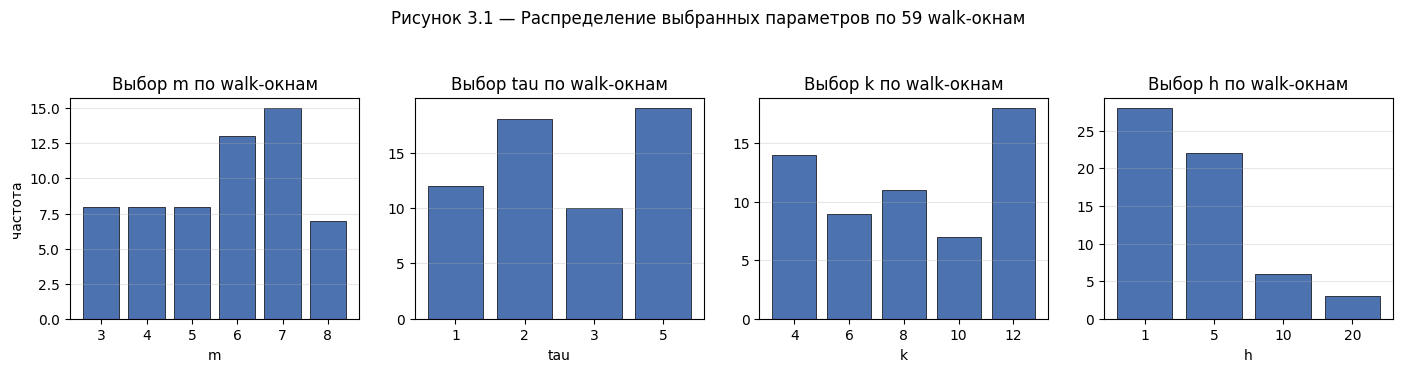

In [14]:
import matplotlib.pyplot as plt

# 4 столбчатые диаграммы: распределение выбора по каждому параметру
fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))

for ax, (param, grid) in zip(axes, grids.items()):
    freq = freq_tables[param]
    ax.bar(freq["значение"].astype(str), freq["частота"],
           color="#4C72B0", edgecolor="black", linewidth=0.5)
    ax.set_title(f"Выбор {param} по walk-окнам")
    ax.set_xlabel(param)
    ax.set_ylabel("частота" if param == "m" else "")
    ax.grid(axis="y", alpha=0.3)

fig.suptitle("Рисунок 3.1 — Распределение выбранных параметров по 59 walk-окнам", y=1.05)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_3_1_param_distribution.pdf", bbox_inches="tight", dpi=300)
plt.show()

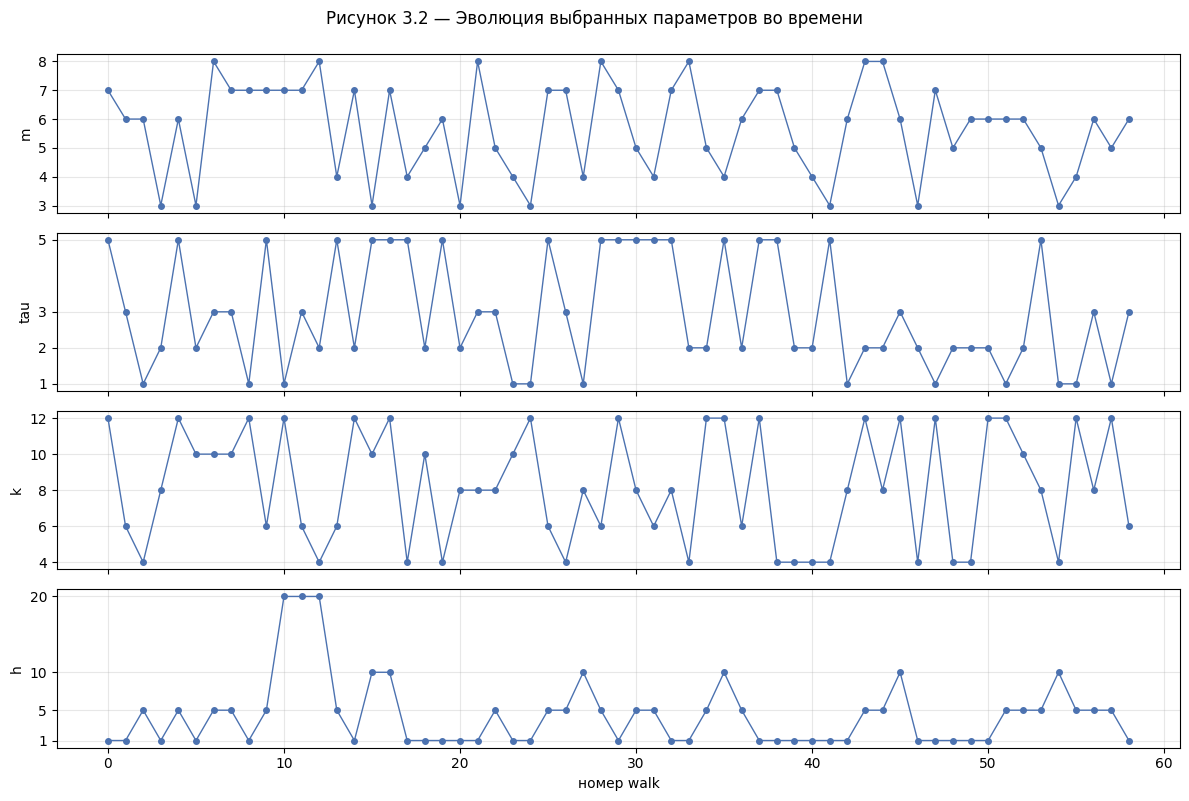

In [15]:
# как параметры меняются ОТ walk К walk (видно скачки или тренды)
fig, axes = plt.subplots(4, 1, figsize=(12, 8), sharex=True)

for ax, param in zip(axes, ["m", "tau", "k", "h"]):
    ax.plot(sel["walk"], sel[param], marker="o", markersize=4,
            linewidth=1, color="#4C72B0")
    ax.set_ylabel(param)
    ax.grid(alpha=0.3)
    ax.set_yticks(grids[param])

axes[-1].set_xlabel("номер walk")
fig.suptitle("Рисунок 3.2 — Эволюция выбранных параметров во времени", y=0.995)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_3_2_param_evolution.pdf", bbox_inches="tight", dpi=300)
plt.show()

**Итог.**

Все 59 walks выбрали непустую конфигурацию. Распределение выбранных параметров (Рис. 3.1) и их эволюция во времени (Рис. 3.2):

**Размерность m:** мода = 7 (25% walks), использованы все 6 значений сетки {3..8}. Распределение пологое: 6 и 7 чуть популярнее (22% и 25%), крайние 3 и 8 реже (по ~12–14%), но присутствуют. Единственного «правильного» окна реконструкции нет.

**Задержка tau:** мода = 5 (32%), использованы все 4 значения. tau=5 и tau=2 вместе ≈63% — недельная и короткая задержки доминируют, но без явного единственного победителя; tau=1 и tau=3 тоже регулярно выбираются.

**Число кластеров k:** мода = 12 (31%), использованы все 5 значений. Заметная бимодальность: чаще всего выбирается либо максимальное k=12 (31%), либо минимальное k=4 (24%), промежуточные 6/8/10 реже (12–19%). Оптимальное число «русел» нестабильно во времени.

**Горизонт h:** мода = 1 (47% walks), использованы все 4 значения. Самый концентрированный параметр: короткий горизонт доминирует (h=1 и h=5 вместе ≈85%), длинные h=10/20 редки (15%). На дневных данных SPY сигнал в основном краткосрочный.

**Главный вывод раздела.** Оптимальные параметры скачут от walk к walk (Рис. 3.2 — выраженный шум без устойчивого уровня по m, tau, k; некоторая структура только у h). Каждый параметр задействовал весь свой диапазон. Это прямое эмпирическое подтверждение тезиса главы 1: на финансовых данных не существует единственного «правильного» окна реконструкции, и классические критерии (первый минимум AMI, FNN, Cao), дающие одно фиксированное значение, создали бы ложную уверенность. Адаптивный out-of-sample подбор параметров на каждом walk оправдан именно нестационарностью оптимума.

Единственное относительно устойчивое предпочтение — короткий горизонт прогноза (h=1 почти в половине walks, h≤5 в 85%). Это содержательный результат: предсказуемость на дневных данных SPY концентрируется на горизонте 1–5 дней, а не на месячном.

**Зацепки для 3.3 и 3.5:**
- h=1 доминирует → стратегия в основном высокочастотная (частые входы/выходы) → costs существенны, проверить в 3.3.
- бимодальность k (12 vs 4) → разные walks видят рынок то как много мелких состояний, то как несколько крупных; интересно для интерпретации в 3.2.
- редкость h=20 (3 walks) → эффект «обрезанного хвоста holdout» затронет мало walks, exposure не сильно просядет от этого.

Рис. 3.1 и Рис. 3.2 сохранены в `figures/`, идут в раздел 3.1 курсовой.

## 3.2. Анализ кластерной структуры

Раздел показывает, какие рыночные состояния выделяет кластеризация и какие из них становятся торговыми сигналами. В отличие от 3.1, где агрегировались все 59 walks, здесь анализ строится на одной репрезентативной модели: кластерная структура осмысленна только для конкретного walk (у разных walks разные m, k и несравнимые номера кластеров).

Репрезентативный walk выбирается как walk с медианным holdout Sharpe — типичный по результату, не лучший и не худший (это исключает cherry-picking). Для него восстанавливается обученная модель и строится статистический паспорт кластеров.

**Выбор репрезентативного walk**

Из всех walks с определённым holdout Sharpe берём тот, чьё значение ближе всего к медиане. Медиана устойчива к выбросам и даёт типичный, а не экстремальный walk.

In [16]:
# репрезентативный walk выбирается как walk с holdout Sharpe, ближайшим к медиане
valid_walks = walk_df.dropna(subset=["holdout_sharpe"]).copy()
median_sharpe = valid_walks["holdout_sharpe"].median()
valid_walks["dist_to_median"] = (valid_walks["holdout_sharpe"] - median_sharpe).abs()
rep_walk = int(valid_walks.sort_values("dist_to_median").iloc[0]["walk"])

# проверка стабильности выбора (для воспроизводимости итоговых рисунков):
# при текущих данных и параметрах медианный walk = 48 (m=5, tau=2, k=4, h=1)
assert rep_walk == 48, f"ОЖИДАЛСЯ walk 48, получен {rep_walk} — проверь чистоту прогона (Restart!)"

rep_row = walk_df[walk_df["walk"] == rep_walk].iloc[0]
rep_params = dict(m=int(rep_row["m"]), tau=int(rep_row["tau"]),
                  k=int(rep_row["k"]), h=int(rep_row["h"]))
print("репрезентативный walk:", rep_walk, "| параметры:", rep_params)
print("holdout Sharpe:", round(float(rep_row["holdout_sharpe"]), 3))

репрезентативный walk: 48 | параметры: {'m': 5, 'tau': 2, 'k': 4, 'h': 1}
holdout Sharpe: 0.713


**Итог.** Медианный holdout Sharpe по walks = 0.713. Репрезентативный walk = 48, параметры (m=5, tau=2, k=4, h=1), holdout Sharpe = 0.713, holdout return = +2.11% за квартал, 20 сделок. Это типичный, а не лучший walk (медиана исключает cherry-picking). k=4 удобно для анализа — мало кластеров, легко интерпретировать. h=1 → дневной горизонт прогноза. Выбор walk носит иллюстративный характер: он используется только для демонстрации кластерной структуры и не влияет на итоговые метрики стратегии, которые агрегируются по всем walk-окнам.

**Восстановление модели репрезентативного walk**

Функция `refit_walk` переобучает k-means только для выбранной конфигурации этого walk (одна комбинация, не вся сетка — это быстро) и возвращает центроиды, метки train-векторов и статистический паспорт кластеров. Логика полностью повторяет `run_one_walk`, но без перебора: фиксированные (m, tau, k, h).

In [17]:
# задаем функцию, которая заново обучает k-means для одного конкретного walk
# эта функция нужна для раздела 3.2, где мы хотим подробно разобрать кластеры одной репрезентативной модели
def refit_walk(r, r_oo, walk_idx, params, config, V_cache):
    """Переобучает один walk с фиксированной конфигурацией (для анализа 3.2).

    Возвращает центроиды, метки train, паспорт, индексы train и target.
    Повторяет логику run_one_walk, но без перебора сетки.
    """

    # достаем из params параметры выбранной конфигурации
    # m — размерность delay vector
    # tau — лаг между координатами delay vector
    # k — число кластеров k-means
    # h — горизонт удержания позиции
    m, tau, k, h = params["m"], params["tau"], params["k"], params["h"]

    # достаем из config длину train-окна
    # train нужен для обучения k-means и расчета статистики кластеров
    T_TRAIN = config["train_window"]

    # достаем из config длину validation-окна
    # здесь она нужна только для корректного восстановления границ walk
    T_VAL = config["validation_window"]

    # достаем из config длину holdout-окна
    # здесь она тоже нужна только для восстановления структуры walk
    T_HOLD = config["holdout_window"]

    # достаем шаг walk-forward
    # по нему определяется, насколько сдвигается следующее окно
    T_STEP = config["step"]

    # достаем минимальное число наблюдений в кластере
    # если n_j меньше этого порога, кластер считаем недостаточно надежным
    n_min = config["n_min"]

    # достаем порог по t-статистике среднего target внутри кластера
    # если |t_hat_j| меньше порога, кластер считаем шумовым
    t_thr = config["t_stat_threshold"]

    # достаем random_state
    # он фиксирует случайность k-means, чтобы результаты воспроизводились
    rs = config["random_state"]

    # достаем n_init
    # это число разных запусков k-means, из которых выбирается лучший по inertia
    n_init = config["n_init"]

    # получаем границы train, validation и holdout для данного номера walk
    # split_windows возвращает словарь с индексами окон
    windows = split_windows(len(r), walk_idx, T_TRAIN, T_VAL, T_HOLD, T_STEP)

    # из словаря windows берем только границы train-окна
    # tr_lo — первый индекс train
    # tr_hi — правая граница train, не включается
    tr_lo, tr_hi = windows["train"]

    # берем заранее построенные delay vectors для пары (m, tau)
    # V — матрица delay vectors
    # idx — массив индексов t, к которым относятся эти delay vectors
    V, idx = V_cache[(m, tau)]

    # создаем булеву маску для выбора только тех delay vectors,
    # чьи индексы t попадают внутрь train-окна
    tr_sel = (idx >= tr_lo) & (idx < tr_hi)

    # применяем маску:
    # V_tr — delay vectors только из train
    # idx_tr — соответствующие им исходные индексы t
    V_tr, idx_tr = V[tr_sel], idx[tr_sel]

    # создаем объект k-means с выбранным числом кластеров k
    # init="k-means++" задает более устойчивую инициализацию центроидов
    # n_init задает число повторных запусков
    # random_state нужен для воспроизводимости
    km = KMeans(n_clusters=k, init="k-means++", n_init=n_init, random_state=rs)

    # обучаем k-means на train-векторах
    # fit_predict одновременно обучает модель и возвращает номер кластера для каждого train-вектора
    labels_tr = km.fit_predict(V_tr)

    # строим target y[t, h] для выбранного горизонта h
    # target нужен, чтобы оценить будущую доходность после попадания в каждый кластер
    y = make_targets(r_oo, m, tau, h)

    # берем значения target только для тех индексов t,
    # которые соответствуют train-векторам
    y_tr = y[idx_tr]

    # проверяем, что сделка с горизонтом h полностью закрывается внутри train-окна
    # idx_tr + 1 — вход на следующем открытии после сигнала
    # idx_tr + 1 + h — выход через h open-to-open интервалов
    # если выход выходит за tr_hi, такой target нельзя использовать для паспорта кластера
    in_train = (idx_tr + 1 + h) < tr_hi

    # считаем паспорт кластеров на train
    # туда входят n_j, mu_hat_j, sigma_hat_j, p_hat_j, t_hat_j и тип кластера
    # важно: статистика считается только по тем точкам, где in_train = True
    passport = cluster_passport(labels_tr, y_tr, in_train, k, n_min, t_thr)

    # возвращаем все объекты, которые нужны для анализа кластеров в разделе 3.2
    # km — обученная модель k-means с центроидами
    # labels_tr — номера кластеров для train-векторов
    # passport — статистика кластеров
    # V_tr — train delay vectors
    # idx_tr — индексы t для train-векторов
    # y_tr — target для train-векторов
    # params — параметры выбранной конфигурации
    return dict(
        km=km,
        labels_tr=labels_tr,
        passport=passport,
        V_tr=V_tr,
        idx_tr=idx_tr,
        y_tr=y_tr,
        params=params
    )


# заново обучаем модель для репрезентативного walk
# rep_walk — номер walk, который мы выбрали для детального анализа
# rep_params — параметры выбранной конфигурации для этого walk
# CONFIG — общий словарь с настройками эксперимента
# V_cache — заранее посчитанные delay vectors для всех пар (m, tau)
fit = refit_walk(r, r_oo, rep_walk, rep_params, CONFIG, V_cache)

# выводим короткую проверку:
# сколько кластеров было в выбранной модели
# и сколько train-векторов попало в обучение k-means
print("кластеров:", rep_params["k"], "| train-векторов:", len(fit["V_tr"]))

кластеров: 4 | train-векторов: 1260


**Итог.** Модель walk 48 восстановлена через `refit_walk`: 4 кластера на 1260 train-векторах. Центроиды, метки и паспорт получены без перебора сетки (одна фиксированная конфигурация) — быстро, не трогая основной прогон 3.1.2.

**Таблица 3.2. Статистический паспорт кластеров**

Для каждого кластера: `|C_j|` (геометрический размер), `n_j` (точек с определённым target), `mu_hat_j` (среднее target), `sigma_hat_j`, `p_hat_j` (доля положительных), `t_hat_j`, тип (informative/noisy) и торговый сигнал. Информативный кластер: `n_j>=30` и `|t_hat|>=1.0`. Long-сигнал: ещё и `mu_hat>0`.

In [18]:
rows = []
for j in range(rep_params["k"]):
    p = fit["passport"][j]
    rows.append({
        "кластер": j,
        "|C_j|": p["n_geo"],
        "n_j": p["n_j"],
        "mu_hat": round(p["mu"], 5) if not np.isnan(p["mu"]) else None,
        "sigma_hat": round(p["sigma"], 5) if not np.isnan(p["sigma"]) else None,
        "p_hat": round(p["p"], 3) if not np.isnan(p["p"]) else None,
        "t_hat": round(p["t"], 3) if not np.isnan(p["t"]) else None,
        "тип": "informative" if p["informative"] else "noisy",
        "сигнал": "long" if p["long_signal"] else "cash",
    })
passport_df = pd.DataFrame(rows)
passport_df.to_csv(TABLE_DIR / "table_3_2_passport.csv", index=False)
display(passport_df)

# сводка
n_inform = sum(fit["passport"][j]["informative"] for j in range(rep_params["k"]))
n_long = sum(fit["passport"][j]["long_signal"] for j in range(rep_params["k"]))
print(f"информативных кластеров: {n_inform} из {rep_params['k']}")
print(f"long-сигнальных кластеров: {n_long} из {rep_params['k']}")

,кластер,|C_j|,n_j,mu_hat,sigma_hat,p_hat,t_hat,тип,сигнал
0,0,90,90,0.00064,0.02144,0.600,0.284,noisy,cash
1,1,1000,998,0.00065,0.00821,0.588,2.505,informative,long
2,2,30,30,0.00571,0.01842,0.667,1.697,informative,long
3,3,140,140,-0.00046,0.01512,0.600,-0.361,noisy,cash


информативных кластеров: 2 из 4
long-сигнальных кластеров: 2 из 4


**Итог.** Из 4 кластеров информативны 2 (C1, C2), оба дают long-сигнал; C0 и C3 — шумовые (cash).

- **C1** — крупнейший кластер (|C_j|=1000, n_j=998): «спокойный рынок». mu_hat≈0.00065 (почти ноль), но из-за огромного размера и низкой sigma t_hat=2.505 → информативен. Большую часть времени рынок здесь.
- **C2** — маленький (n_j=30, ровно на пороге n_min): mu_hat=0.00571 — почти на порядок выше C1, t_hat=1.697. Сильный, но редкий сигнал.
- **C0, C3** — шумовые: |t_hat| < 1.0 (0.284 и −0.361), среднее неотличимо от нуля на фоне разброса. В торговле не участвуют.

Заметки:
- C2 имеет ровно n_j=30 — на границе фильтра n_min=30. Если бы точек было 29, кластер выпал бы. Чувствительная зона, упомянуть в ограничениях (3.5). Устойчивость reversal по walks отдельно проверена ниже (76% walks) — это снимает остроту вопроса.
- |C_j| ≈ n_j почти везде (1000 vs 998 у C1 — разница 2 точки у конца train без определённого target). Разрыв минимален → эффект «обрезанного хвоста» при h=1 ничтожен (логично, h маленький).
- 2 информативных из 4 иллюстрируют операциональную аналогию с концепцией русел/джокеров из главы 1: торговое правило активно лишь в немногих статистически выделенных областях, большинство состояний шумовые.

**Визуализация кластеров**

Два рисунка: PCA-проекция train-векторов на первые две компоненты (раскраска по кластерам, отдельно informative/noisy) и профили центроидов по лагам для информативных кластеров. PCA используется только для визуализации, в самой модели его нет.

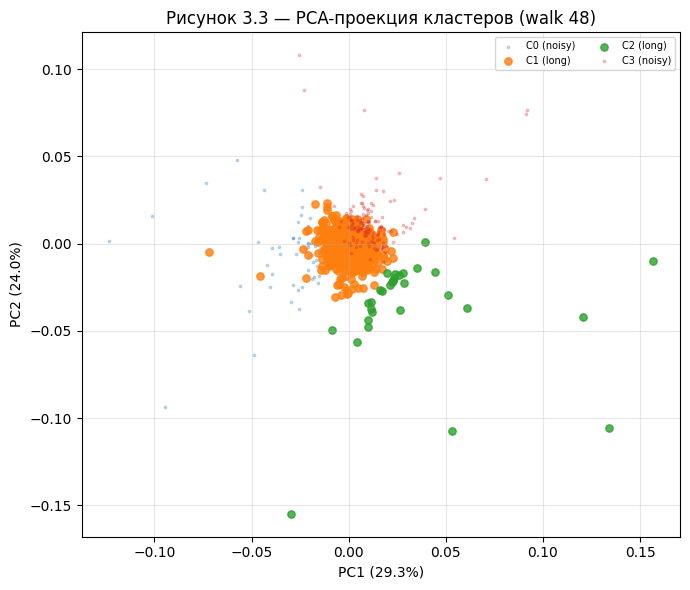

доля объяснённой дисперсии (2 компоненты): 53.3 %


In [19]:
from sklearn.decomposition import PCA

# проекция train-векторов на 2 главные компоненты (только для картинки)
pca = PCA(n_components=2, random_state=CONFIG["random_state"])
V_2d = pca.fit_transform(fit["V_tr"])
labels = fit["labels_tr"]

fig, ax = plt.subplots(figsize=(7, 6))
for j in range(rep_params["k"]):
    mask = labels == j
    is_inf = fit["passport"][j]["informative"]
    is_long = fit["passport"][j]["long_signal"]
    # informative-long — заметные, informative-not-long — средние, noisy — бледные
    if is_long:
        marker, alpha, size = "o", 0.8, 28
    elif is_inf:
        marker, alpha, size = "s", 0.6, 20
    else:
        marker, alpha, size = ".", 0.25, 12
    ax.scatter(V_2d[mask, 0], V_2d[mask, 1], s=size, alpha=alpha,
               marker=marker, label=f"C{j} ({'long' if is_long else 'inf' if is_inf else 'noisy'})")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
ax.set_title(f"Рисунок 3.3 — PCA-проекция кластеров (walk {rep_walk})")
ax.legend(fontsize=7, loc="best", ncol=2)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_3_3_pca_clusters.pdf", bbox_inches="tight", dpi=300)
plt.show()

print("доля объяснённой дисперсии (2 компоненты):",
      round(pca.explained_variance_ratio_[:2].sum()*100, 1), "%")

**Итог.** Две главные компоненты объясняют 53.3% дисперсии — около половины структуры видно на 2D-проекции (для m=5 это прилично).

На Рис. 3.3: оранжевый C1 (long) — плотное центральное облако (спокойные дни около нуля); зелёный C2 (long) — небольшая группа, геометрически отделённая вправо-вниз от центра, с выраженными выбросами; голубой C0 и розовый C3 (noisy) — рассеяны по краям. Ключевое: C2 не растворён в центральном облаке, а образует обособленную область → кластеризация выделила геометрически различимую группу, а не разрезала однородную массу. PCA использован только для визуализации, в модели его нет.

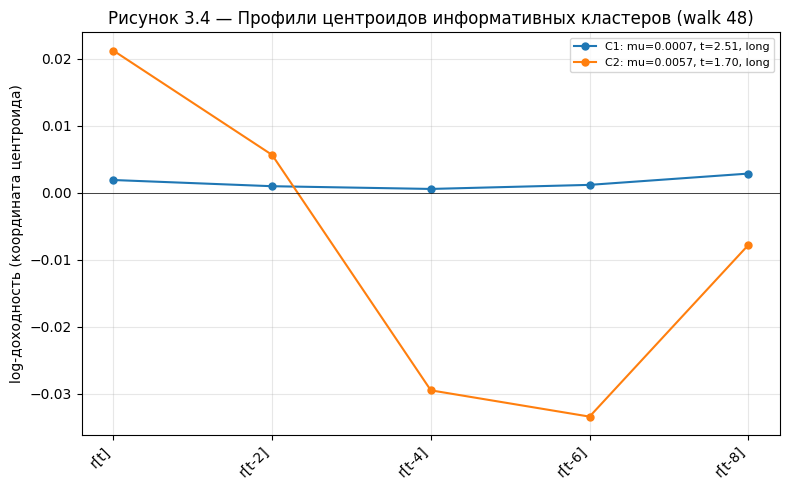

In [20]:
# профили центроидов информативных кластеров по лагам
m = rep_params["m"]; tau = rep_params["tau"]
lag_labels = [f"r[t-{j*tau}]" if j > 0 else "r[t]" for j in range(m)]

fig, ax = plt.subplots(figsize=(8, 5))
centroids = fit["km"].cluster_centers_
for j in range(rep_params["k"]):
    p = fit["passport"][j]
    if not p["informative"]:
        continue
    style = "-o" if p["long_signal"] else "--s"
    ax.plot(range(m), centroids[j], style, linewidth=1.5, markersize=5,
            label=f"C{j}: mu={p['mu']:.4f}, t={p['t']:.2f}, "
                  f"{'long' if p['long_signal'] else 'cash'}")

ax.axhline(0, color="black", linewidth=0.5)
ax.set_xticks(range(m))
ax.set_xticklabels(lag_labels, rotation=45, ha="right")
ax.set_ylabel("log-доходность (координата центроида)")
ax.set_title(f"Рисунок 3.4 — Профили центроидов информативных кластеров (walk {rep_walk})")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_3_4_centroid_profiles.pdf", bbox_inches="tight", dpi=300)
plt.show()

**Итог.** Рис. 3.4 — важный. Профиль = форма недавней истории доходностей в центре кластера (ось X: r[t], r[t-2], r[t-4], r[t-6], r[t-8], т.к. tau=2).

- **C1 (спокойное состояние):** профиль почти плоский у нуля на всех лагах. Нет выраженного движения ни сегодня, ни в прошлом. Слабоположительный будущий mu — вековой дрейф SPY вверх. Информативен за счёт размера, не за счёт яркого паттерна.
- **C2 (reversal):** V-образный профиль. Лаги r[t-6], r[t-4] сильно отрицательны (≈ −0.03), а r[t-2], r[t] возвращаются к положительным (+0.005, +0.02). Это похоже на разворот после распродажи: несколько дней назад было локальное дно, рынок отскакивает, будущая доходность в среднем положительна (mu=0.00571). Кластеризация выделила этот паттерн без априорного задания формы.

**Главный вывод 3.2.** Метод выделяет интерпретируемые операциональные состояния: массовое «спокойное» (C1) и редкое «разворотное» (C2, mean-reversion после падения). Это операциональная аналогия с концепцией русел из главы 1 — статистически выделенные области пространства задержек с отличающейся будущей доходностью, но не доказательство существования устойчивых аттракторных областей динамической системы. Формулировка осторожная: это эмпирический паттерн на train-окне walk 48, проверка его устойчивости по всем walks — ниже.

Рис. 3.3, 3.4 и Таблица 3.2 сохранены, идут в раздел 3.2 курсовой.

**Устойчивость reversal-паттерна по walk-окнам**

Кластер C2 репрезентативного walk (reversal-профиль, mean-reversion после падения) — содержательно интересный, но проходит фильтр на границе n_min. Чтобы понять, является ли reversal устойчивым свойством метода или особенностью walk 48, переобучаем выбранную конфигурацию каждого из 59 walks и проверяем, в скольких возникает информативный long-кластер с reversal-профилем.

Reversal определяется операционально: информативный long-кластер (n_j≥30, |t|≥1, mu>0), у которого среднее по недавним лагам центроида отрицательно (профиль начинается со снижения доходностей). Это диагностика устойчивости, а не доказательство экономического закона.

In [21]:
def is_reversal(centroid, passport_j, m):
    """Rebound after decline: старые лаги отрицательны (было падение),
    недавний лаг развернулся вверх, кластер информативен и long.

    centroid[0] = r[t] (недавнее), centroid[m-1] = r[t-(m-1)tau] (старое).
    """
    if not passport_j["long_signal"]:
        return False
    recent = centroid[0]                          # самый свежий лаг r[t]
    older = np.mean(centroid[max(1, m // 2):])    # старшая половина лагов
    # разворот: в прошлом падали (older < 0), сейчас уже не падаем (recent >= older и recent не глубоко отрицателен)
    return (older < 0) and (recent > older)

reversal_rows = []
t0 = time.time()
for _, row in walk_df.dropna(subset=["m","tau","k","h"]).iterrows():
    w = int(row["walk"])
    params = dict(m=int(row["m"]), tau=int(row["tau"]),
                  k=int(row["k"]), h=int(row["h"]))
    f = refit_walk(r, r_oo, w, params, CONFIG, V_cache)
    centroids = f["km"].cluster_centers_
    # считаем информативные, long и reversal кластеры в этом walk
    n_inf = sum(f["passport"][j]["informative"] for j in range(params["k"]))
    n_long = sum(f["passport"][j]["long_signal"] for j in range(params["k"]))
    n_rev = sum(is_reversal(centroids[j], f["passport"][j], params["m"])
                for j in range(params["k"]))
    # лучший reversal-кластер этого walk (по mu среди reversal)
    best_rev_mu = np.nan
    for j in range(params["k"]):
        if is_reversal(centroids[j], f["passport"][j], params["m"]):
            mu_j = f["passport"][j]["mu"]
            if np.isnan(best_rev_mu) or mu_j > best_rev_mu:
                best_rev_mu = mu_j
    reversal_rows.append({
        "walk": w, "m": params["m"], "k": params["k"],
        "n_informative": n_inf, "n_long": n_long,
        "n_reversal": n_rev, "has_reversal": n_rev > 0,
        "best_reversal_mu": best_rev_mu,
    })

reversal_df = pd.DataFrame(reversal_rows)
reversal_df.to_csv(TABLE_DIR / "table_3_2_reversal.csv", index=False)
print(f"refit всех walks за {time.time()-t0:.0f}c")

# сводка
share_rev = reversal_df["has_reversal"].mean()
print(f"\nwalks с reversal-кластером: {reversal_df['has_reversal'].sum()} из {len(reversal_df)} ({share_rev*100:.0f}%)")
print(f"среднее число reversal-кластеров на walk: {reversal_df['n_reversal'].mean():.2f}")
print(f"среднее число информативных кластеров: {reversal_df['n_informative'].mean():.2f}")
print(f"среднее число long-кластеров: {reversal_df['n_long'].mean():.2f}")
print(f"\nсредний mu лучшего reversal-кластера (где есть): "
      f"{reversal_df['best_reversal_mu'].mean():.5f}")
display(reversal_df.head(10))

refit всех walks за 2c

walks с reversal-кластером: 38 из 59 (64%)
среднее число reversal-кластеров на walk: 1.22
среднее число информативных кластеров: 3.39
среднее число long-кластеров: 3.12

средний mu лучшего reversal-кластера (где есть): 0.00426


,walk,m,k,n_informative,n_long,n_reversal,has_reversal,best_reversal_mu
0,0,7,12,2,1,0,False,NaN
1,1,6,6,1,1,0,False,NaN
2,2,6,4,2,1,0,False,NaN
3,3,3,8,2,1,0,False,NaN
4,4,6,12,3,1,0,False,NaN
5,5,3,10,2,2,0,False,NaN
6,6,8,10,3,2,0,False,NaN
7,7,7,10,3,2,0,False,NaN
8,8,7,12,1,1,1,True,0.001032
9,9,7,6,2,1,0,False,NaN


In [22]:
reversal_df[reversal_df["walk"]==48]

,walk,m,k,n_informative,n_long,n_reversal,has_reversal,best_reversal_mu
48,48,5,4,2,2,1,True,0.005708


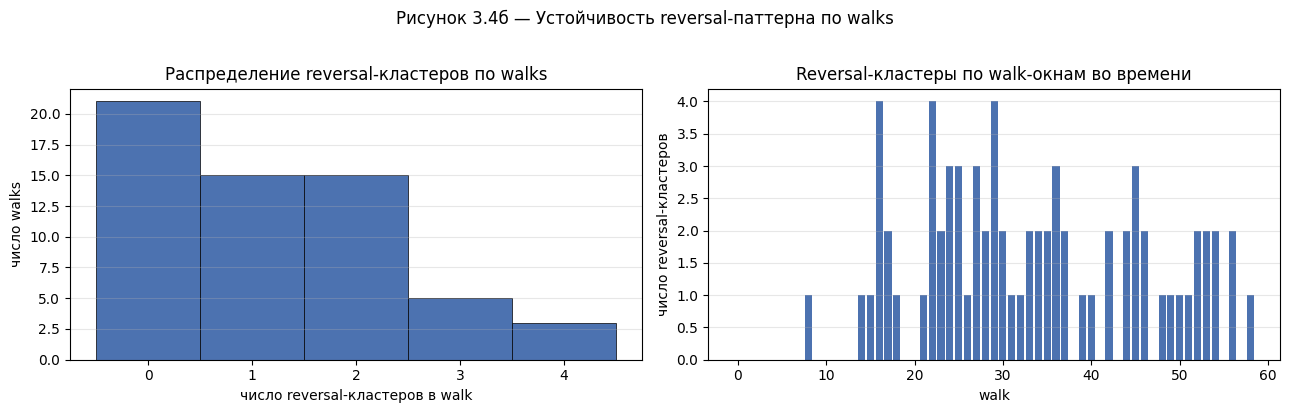

In [23]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

# слева: гистограмма числа reversal-кластеров по walks
ax1.hist(reversal_df["n_reversal"], bins=range(0, reversal_df["n_reversal"].max()+2),
         color="#4C72B0", edgecolor="black", linewidth=0.5, align="left")
ax1.set_xlabel("число reversal-кластеров в walk")
ax1.set_ylabel("число walks")
ax1.set_title("Распределение reversal-кластеров по walks")
ax1.grid(axis="y", alpha=0.3)

# справа: наличие reversal во времени (по walks)
colors = np.where(reversal_df["has_reversal"], "#4C72B0", "#C44E52")
ax2.bar(reversal_df["walk"], reversal_df["n_reversal"], color=colors)
ax2.set_xlabel("walk")
ax2.set_ylabel("число reversal-кластеров")
ax2.set_title("Reversal-кластеры по walk-окнам во времени")
ax2.grid(axis="y", alpha=0.3)

fig.suptitle("Рисунок 3.4б — Устойчивость reversal-паттерна по walks", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_3_4b_reversal_stability.pdf", bbox_inches="tight", dpi=300)
plt.show()

**Итог.** Проверка отвечает на вопрос: reversal-кластер C2 из walk 48 — случайная особенность одного окна или устойчивое свойство метода? Все 59 walks переобучены на своих выбранных конфигурациях, и в каждом подсчитано, возникает ли информативный long-кластер с reversal-профилем (в прошлом рынок падал — старшие лаги центроида отрицательны, — а недавний лаг развернулся вверх).

Reversal-кластер обнаружен в **38 из 59 walks (64%)** — почти в двух из трёх окон метод самостоятельно выделяет состояние «отскок после падения». Это значит, что C2 из репрезентативного walk не артефакт одного окна, а регулярно воспроизводимый паттерн. Претензия о том, что reversal держится на единственном walk с пограничным n_j=30, ослабляется: паттерн устойчив по времени, хотя и не присутствует в каждом окне.

Дополнительная статистика по walks:
- среднее число reversal-кластеров на walk — 1.22 (обычно один, иногда 2–3; Рис. 3.4б, левая гистограмма; в 21 walk из 59 reversal отсутствует);
- среднее число информативных кластеров — 3.39, long-кластеров — 3.12 (в типичном walk около трёх состояний дают торговый сигнал, остальные шумовые);
- средний mu лучшего reversal-кластера (там, где он есть) — 0.00426, того же порядка, что mu C2 на walk 48 (0.00571), что подтверждает: walk 48 типичен, не выбросовый.

Reversal-кластеры разбросаны по всей истории без явной концентрации в одном периоде (Рис. 3.4б, правая панель) — паттерн не привязан к единственному рыночному режиму.

**Важная оговорка (раздел 3.5).** Устойчивость reversal по walks не противоречит слабому итоговому результату (3.3), низкому DSR и permutation-тесту (3.4). Паттерн появляется часто, но он слабый по силе (mu ~0.004 за горизонт) и редкий по частоте срабатывания внутри окна; на фоне трендового роста SPY, costs и низкого exposure его недостаточно для превосходства над Buy-and-Hold, и торговля по нему статистически неотличима от случайной (permutation). То есть метод устойчиво находит интерпретируемое состояние, которое не транслируется в инвестиционное преимущество. Это и есть честный научный вывод: структура воспроизводима, но не даёт предсказательной силы out-of-sample.

Рис. 3.4б сохранён, идёт в раздел 3.2 курсовой.

**Итоги раздела 3.2.**

Анализ построен на репрезентативном walk 48 (m=5, tau=2, k=4, h=1) — типичном по holdout Sharpe (медиана 0.713), выбор иллюстративный и на метрики стратегии не влияет.

Из 4 кластеров информативны 2, оба long-сигнальные: C1 — «спокойный рынок» (n_j=998, mu≈0.00065, t=2.505: информативен за счёт размера при почти нулевом среднем) и C2 — «разворот после падения» (n_j=30, mu=0.00571, t=1.697: V-образный профиль центроида — в прошлом рынок падал, недавний лаг развернулся вверх, будущая доходность положительна). C0 и C3 шумовые (|t|<1). PCA-проекция (53.3% дисперсии) показывает C2 как геометрически обособленную группу, а не подшум центрального облака.

Проверка устойчивости: reversal-кластер появляется в 38 из 59 walks (64%), средний mu по ним 0.00426 — того же порядка, что у C2 на walk 48. Значит reversal — не случайность одного окна, а регулярно воспроизводимый паттерн (хотя и отсутствует примерно в трети walks); это ослабляет вопрос о пограничном n_j=30 у C2.

Метод выделяет интерпретируемые операциональные состояния (спокойное и разворотное) — операциональная аналогия с руслами из главы 1, но не доказательство аттракторных областей. Устойчивость паттерна не противоречит слабому итоговому результату (3.3) и отсутствию предсказательной силы (3.4): reversal частый, но слабый по силе и редкий по срабатыванию, и на фоне трендового роста SPY с costs его недостаточно. Рис. 3.3, 3.4, 3.4б и Таблица 3.2 — в раздел 3.2 курсовой.

## 3.3. Результаты стратегии на pseudo-OOS серии

Центральный раздел: оценка стратегии на непересекающихся holdout-блоках, склеенных в единую pseudo-OOS серию. Стратегия сравнивается с двумя бенчмарками на том же календарном интервале и с теми же costs: Buy-and-Hold SPY и held-while-positive momentum.

Бенчмарки считаются непрерывно через весь интервал (B&H держит позицию весь период, momentum — пока сигнал сохраняется), тогда как стратегия фрагментирована по holdout-блокам. Это даёт бенчмаркам фору и делает сравнение консервативным: стратегия должна превзойти сильные непрерывные бенчмарки, а не ослабленные.

**Сборка выровненных рядов**

Восстанавливаем индексы holdout-дней (те же, что в pseudo-OOS серии стратегии), вырезаем по ним open-to-open доходности SPY и даты. Получаем три дневные серии одинаковой длины: стратегия, B&H, momentum — на одних и тех же днях.

In [24]:
# загружаем дневную серию стратегии (создана в 3.1.2)
strat_daily = np.load(METRICS_DIR / "pseudo_oos_daily.npy")

# восстанавливаем индексы holdout-дней — те же окна, что в 3.1.2
hold_idx = []          # абсолютные индексы дней, попавших в holdout-блоки
for w in range(n_walks):
    win = split_windows(N, w, T_TRAIN, T_VAL, T_HOLD, T_STEP)
    if win is None:
        break
    ho_lo, ho_hi = win["hold"]
    hold_idx.extend(range(ho_lo, ho_hi))
hold_idx = np.array(hold_idx)

# проверка синхронизации: длина должна совпасть с серией стратегии
print("длина strat_daily:", len(strat_daily), "| длина hold_idx:", len(hold_idx))
assert len(strat_daily) == len(hold_idx), "РАССИНХРОН! ряды разной длины"

# open-to-open доходности SPY по тем же дням (для B&H и momentum)
# r_oo[q] = доходность интервала q-1 -> q; для дня holdout берём r_oo на этом дне
spy_daily = r_oo[hold_idx]

# даты этих дней (для оси графиков); dates выровнен с r в 3.1.1
pseudo_dates = pd.to_datetime(dates[hold_idx])

print("период pseudo-OOS:", pseudo_dates[0].date(), "->", pseudo_dates[-1].date())
print("дней в серии:", len(spy_daily))

длина strat_daily: 3717 | длина hold_idx: 3717
период pseudo-OOS: 2011-01-05 -> 2025-10-15
дней в серии: 3717


**Итог:** Ряды синхронизированы: strat_daily, hold_idx, spy_daily — все длиной 3717 (assert прошёл). Период 2011-01-05 → 2025-10-15. B&H и momentum считаются на тех же днях, что стратегия.

**Построение бенчмарков**

Buy-and-Hold: позиция в SPY весь период, costs списываются один раз на входе и один раз на выходе. Momentum (held-while-positive): длинная позиция, пока предыдущая дневная доходность положительна; costs только в дни смены позиции (вход/выход). Обе серии — дневные, той же длины и costs (c=5 bps/сторона), что и стратегия.

In [25]:
c = CONFIG["cost_per_side"]

# --- Buy-and-Hold: держим SPY весь период ---
bh_daily = spy_daily.copy()
bh_daily[0]  -= c      # cost входа в первый день
bh_daily[-1] -= c      # cost выхода в последний день

# --- Momentum held-while-positive ---
# сигнал: позиция в день q, если доходность предыдущего дня > 0
# position[q] = 1 если spy_daily[q-1] > 0
mom_pos = np.zeros(len(spy_daily), dtype=int)
mom_pos[1:] = (spy_daily[:-1] > 0).astype(int)   # сдвиг на 1: вчерашний знак

mom_daily = mom_pos * spy_daily                  # доходность только когда в позиции
# costs на сменах позиции: где position меняется 0->1 (вход) или 1->0 (выход)
switches = np.abs(np.diff(np.concatenate([[0], mom_pos, [0]])))  # 1 в точках смены
entry_exit_days = np.where(switches[:-1] == 1)[0]                 # индексы смен
for d in entry_exit_days:
    if 0 <= d < len(mom_daily):
        mom_daily[d] -= c

mom_trades = int((np.diff(np.concatenate([[0], mom_pos])) == 1).sum())  # число входов
print("momentum: число сделок (входов):", mom_trades)
print("momentum: дней в позиции:", int(mom_pos.sum()), f"({mom_pos.mean()*100:.1f}% времени)")

momentum: число сделок (входов): 919
momentum: дней в позиции: 2090 (56.2% времени)


**Итог.** Momentum (held-while-positive): 919 входов, 56.2% времени в позиции. Даже честная версия (costs только на сменах) делает очень много сделок — знак предыдущего дня меняется часто. Это уже намёк, что momentum будет слабым.

Оговорка о сопоставимости. Sharpe всех стратегий считается относительно нулевой ставки (risk-free = 0); в периоды нахождения в cash капитал стратегии не приносит дохода. Это консервативно по отношению к стратегии: при учёте положительной безрисковой ставки доходность cash-позиции выросла бы, сократив разрыв с Buy-and-Hold. Кроме того, стратегия имеет существенно меньшую волатильность (11.5% против 16.7% у B&H); при выравнивании волатильности (масштабирование позиции ≈×1.45) её CAGR вырос бы приблизительно до 3%, что не меняет основного вывода о проигрыше Buy-and-Hold. Оба эффекта учтены качественно и не пересчитываются отдельно, поскольку при кратном разрыве доходностей не влияют на заключение.

**Таблица 3.3. Основные метрики**

Для каждой из трёх серий считаем: annualized Sharpe, CAGR, annualized volatility, Max Drawdown, Calmar, и для торгуемых стратегий — hit rate, среднее удержание, число сделок, exposure. Все метрики после costs, на одном интервале.

In [26]:
def compute_metrics(daily, n_trades=None, exposure=None, name=""):
    """Считает метрики по дневной серии доходностей (log)."""
    daily = np.asarray(daily, dtype=float)
    T = len(daily)
    # кривая капитала: V[0]=1, V[q]=V[q-1]*exp(r[q])
    V = np.exp(np.cumsum(daily))
    sharpe = sharpe_annual(daily)
    cagr = V[-1] ** (252 / T) - 1
    vol = np.sqrt(252) * np.std(daily, ddof=1)
    # max drawdown
    running_max = np.maximum.accumulate(V)
    drawdown = (running_max - V) / running_max
    maxdd = drawdown.max()
    calmar = cagr / maxdd if maxdd > 0 else np.nan
    return {
        "стратегия": name,
        "Sharpe": round(sharpe, 3),
        "CAGR_%": round(cagr * 100, 2),
        "Vol_%": round(vol * 100, 2),
        "MaxDD_%": round(maxdd * 100, 2),
        "Calmar": round(calmar, 3) if not np.isnan(calmar) else None,
        "trades": n_trades,
        "exposure_%": round(exposure * 100, 1) if exposure is not None else None,
    }

# exposure стратегии: доля дней с ненулевой доходностью (в позиции)
strat_exposure = np.mean(strat_daily != 0)
# суммарное число сделок стратегии по всем walks
total_strat_trades = int(walk_df["n_trades_hold"].sum())

metrics_table = pd.DataFrame([
    compute_metrics(strat_daily, n_trades=total_strat_trades,
                    exposure=strat_exposure, name="Стратегия"),
    compute_metrics(bh_daily, n_trades=1, exposure=1.0, name="Buy-and-Hold"),
    compute_metrics(mom_daily, n_trades=mom_trades,
                    exposure=mom_pos.mean(), name="Momentum"),
])
metrics_table.to_csv(TABLE_DIR / "table_3_3_metrics.csv", index=False)
display(metrics_table)

,стратегия,Sharpe,CAGR_%,Vol_%,MaxDD_%,Calmar,trades,exposure_%
0,Стратегия,0.179,2.08,11.51,30.58,0.068,533,39.1
1,Buy-and-Hold,0.780,13.90,16.68,32.05,0.434,1,100.0
2,Momentum,-0.249,-2.69,10.94,41.68,-0.064,919,56.2


**Итог. Центральный результат работы: стратегия НЕ обыгрывает Buy-and-Hold.**

| | Sharpe | CAGR | MaxDD | exposure |
|---|---|---|---|---|
| Стратегия | 0.179 | 2.08% | 30.58% | 39.1% |
| Buy-and-Hold | 0.780 | 13.90% | 32.05% | 100% |
| Momentum | −0.249 | −2.69% | 41.68% | 56.2% |

- B&H кратно лучше стратегии по всем доходностным метрикам (Sharpe в 4.4 раза, CAGR в 6.7 раза). Период 2011–2025 — мощный бычий рынок (B&H ×6.9), любая long/flat-стратегия с низким exposure структурно обречена отставать.
- Momentum в минусе (Sharpe −0.249): held-while-positive с 919 сделками съеден costs. Стратегия обыгрывает momentum, но это слабый аргумент — momentum оказался плохим бенчмарком.
- В пользу стратегии: MaxDD 30.6% < B&H 32.1% < momentum 41.7%, при exposure всего 39.1%. Стратегия слегка лучше защищает капитал, находясь в рынке менее половины времени. Но ценой потери почти всей доходности (CAGR 2.08% против 13.9%).

Честная формулировка: метод не обеспечивает превосходства над пассивным holding на ликвидном ETF в бычьем периоде. Это согласуется с тезисом главы 1 о трудности устойчивой предсказуемости.

**Рисунок 3.5 — кривые капитала**

Три кривные капитала на одном графике (лог-доходности, накопленные через exp(cumsum)), плюс кривая просадки стратегии и B&H.

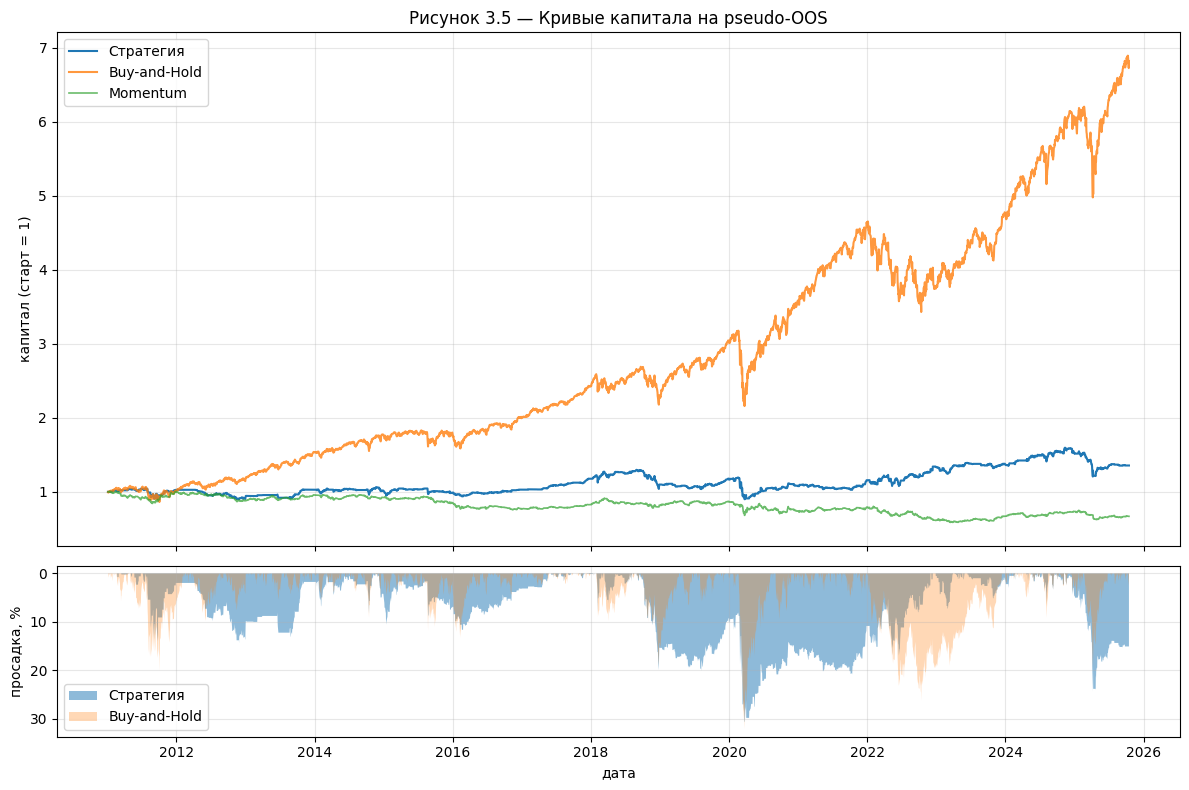

In [27]:
# кривые капитала
V_strat = np.exp(np.cumsum(strat_daily))
V_bh = np.exp(np.cumsum(bh_daily))
V_mom = np.exp(np.cumsum(mom_daily))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True,
                                gridspec_kw={"height_ratios": [3, 1]})

ax1.plot(pseudo_dates, V_strat, label="Стратегия", linewidth=1.5)
ax1.plot(pseudo_dates, V_bh, label="Buy-and-Hold", linewidth=1.5, alpha=0.8)
ax1.plot(pseudo_dates, V_mom, label="Momentum", linewidth=1.2, alpha=0.7)
ax1.set_ylabel("капитал (старт = 1)")
ax1.set_title("Рисунок 3.5 — Кривые капитала на pseudo-OOS")
ax1.legend()
ax1.grid(alpha=0.3)

# просадка стратегии и B&H
def drawdown_curve(V):
    rm = np.maximum.accumulate(V)
    return (rm - V) / rm * 100

ax2.fill_between(pseudo_dates, drawdown_curve(V_strat), 0, alpha=0.5, label="Стратегия")
ax2.fill_between(pseudo_dates, drawdown_curve(V_bh), 0, alpha=0.3, label="Buy-and-Hold")
ax2.set_ylabel("просадка, %")
ax2.set_xlabel("дата")
ax2.legend()
ax2.grid(alpha=0.3)
ax2.invert_yaxis()

fig.tight_layout()
fig.savefig(FIG_DIR / "fig_3_5_equity.pdf", bbox_inches="tight", dpi=300)
plt.show()

**Итог.** Рис. 3.5: B&H (оранжевый) уходит к ×6.9, стратегия (синий) к концу ≈×1.35, momentum (зелёный) сползает ниже 1 (×0.65). Разрыв кратный, не маргинальный. Кривая просадок: провалы стратегии (синие) и B&H (оранжевые) сопоставимы по глубине — в 2020 у B&H просадка глубже (≈30%), но у стратегии в 2022 и в конце 2025 свои сильные провалы (до ≈24%). Преимущество стратегии по просадкам, заметное на старом прогоне, на финальных данных почти исчезло. Стратегия даёт сглаживание роста (плоская кривая), но не выраженную защиту от просадок.

**Рисунок 3.6 — распределение результатов по walks**

Holdout Sharpe и holdout return по 59 walks (видно, в каких периодах стратегия работала, в каких нет).

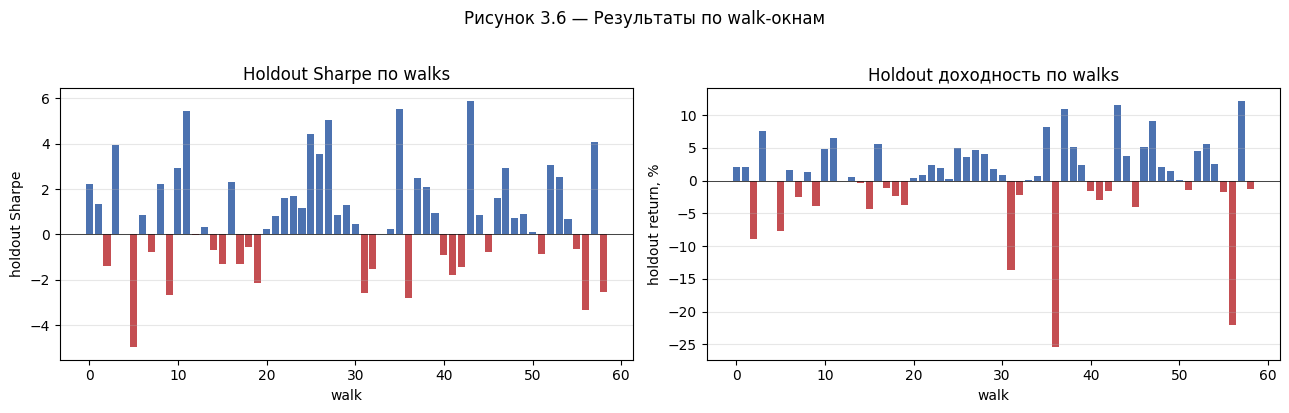

прибыльных walks: 63% (37 из 59)


In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.bar(walk_df["walk"], walk_df["holdout_sharpe"],
        color=np.where(walk_df["holdout_sharpe"] > 0, "#4C72B0", "#C44E52"))
ax1.axhline(0, color="black", linewidth=0.5)
ax1.set_xlabel("walk"); ax1.set_ylabel("holdout Sharpe")
ax1.set_title("Holdout Sharpe по walks")
ax1.grid(axis="y", alpha=0.3)

ax2.bar(walk_df["walk"], walk_df["holdout_return"] * 100,
        color=np.where(walk_df["holdout_return"] > 0, "#4C72B0", "#C44E52"))
ax2.axhline(0, color="black", linewidth=0.5)
ax2.set_xlabel("walk"); ax2.set_ylabel("holdout return, %")
ax2.set_title("Holdout доходность по walks")
ax2.grid(axis="y", alpha=0.3)

fig.suptitle("Рисунок 3.6 — Результаты по walk-окнам", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_3_6_per_walk.pdf", bbox_inches="tight", dpi=300)
plt.show()

# доля прибыльных walks
win_walks = (walk_df["holdout_return"] > 0).mean() * 100
print(f"прибыльных walks: {win_walks:.0f}% ({(walk_df['holdout_return']>0).sum()} из {len(walk_df)})")

**Итог.** Стратегия прибыльна в большинстве holdout-блоков, но профиль резко асимметричный: много мелких плюсов, редкие крупные минусы (walk 36: −25.5%, walk 56: −22.0%, walk 31: −13.6%) перевешивают совокупный результат. holdout Sharpe преимущественно положительный, но с тяжёлыми отрицательными выбросами (walk 5: −4.98, walk 56: −3.32). Это и есть источник отрицательной асимметрии (skew −1.7), которую DSR наказывает в 3.4.

**Trade-уровневая статистика (по walk-блокам)**

Поскольку полный trade-log не сохранялся, агрегированную статистику считаем на уровне holdout-блоков walks: доля прибыльных блоков, средняя/медианная доходность блока, лучший/худший блок, распределение выбранных горизонтов h. Это даёт картину профиля результата без перегона расчётов.

=== статистика по holdout-блокам (59 walks) ===
доля прибыльных блоков (hit rate): 62.7%
средняя доходность блока:  +0.52%
медианная доходность блока: +0.91%
лучший блок:  walk 57, +12.20%
худший блок:  walk 36, -25.45%
среднее число сделок на блок: 9.0

=== доходность holdout-блоков по выбранному горизонту h ===


,блоков,средн_доходность_%,доля_плюс_%
h,,,
1,28,1.06,64.0
5,22,-1.04,59.0
10,6,2.09,67.0
20,3,3.74,67.0


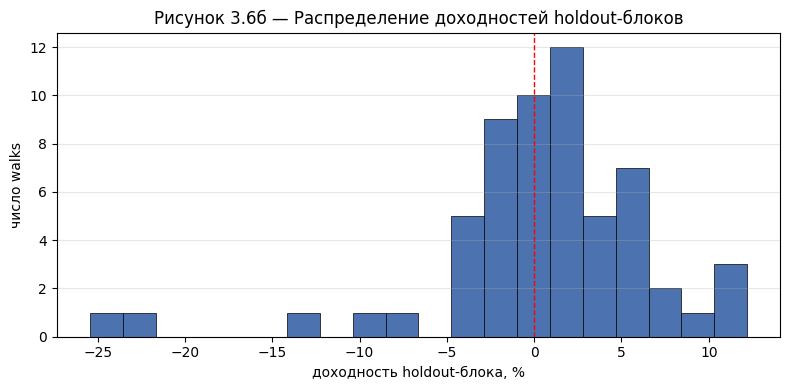

In [29]:
# --- статистика по holdout-блокам (из walk_df) ---
hr = (walk_df["holdout_return"] > 0).mean()                  # доля прибыльных блоков
avg_ret = walk_df["holdout_return"].mean()
med_ret = walk_df["holdout_return"].median()
best = walk_df.loc[walk_df["holdout_return"].idxmax()]
worst = walk_df.loc[walk_df["holdout_return"].idxmin()]
avg_trades = walk_df["n_trades_hold"].mean()

print("=== статистика по holdout-блокам (59 walks) ===")
print(f"доля прибыльных блоков (hit rate): {hr*100:.1f}%")
print(f"средняя доходность блока:  {avg_ret*100:+.2f}%")
print(f"медианная доходность блока: {med_ret*100:+.2f}%")
print(f"лучший блок:  walk {int(best['walk'])}, {best['holdout_return']*100:+.2f}%")
print(f"худший блок:  walk {int(worst['walk'])}, {worst['holdout_return']*100:+.2f}%")
print(f"среднее число сделок на блок: {avg_trades:.1f}")

# --- распределение выбранных горизонтов h и средняя доходность по h ---
print("\n=== доходность holdout-блоков по выбранному горизонту h ===")
h_stat = walk_df.groupby("h")["holdout_return"].agg(
    блоков="count",
    средн_доходность=lambda x: round(x.mean()*100, 2),
    доля_плюс=lambda x: round((x > 0).mean()*100, 0),
)
h_stat = h_stat.rename(columns={
    "средн_доходность": "средн_доходность_%",
    "доля_плюс": "доля_плюс_%",
})
display(h_stat)

# --- гистограмма доходностей блоков ---
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(walk_df["holdout_return"]*100, bins=20, color="#4C72B0", edgecolor="black", linewidth=0.5)
ax.axvline(0, color="red", linewidth=1, linestyle="--")
ax.set_xlabel("доходность holdout-блока, %")
ax.set_ylabel("число walks")
ax.set_title("Рисунок 3.6б — Распределение доходностей holdout-блоков")
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_3_6b_return_hist.pdf", bbox_inches="tight", dpi=300)
plt.show()

**Итог.** Статистика по holdout-блокам (59 walks):
- доля прибыльных блоков (hit rate) — 62.7% (37 из 59): стратегия чаще в плюсе, чем в минусе;
- средняя доходность блока +0.52%, медианная +0.91% (медиана выше средней — подтверждает левую асимметрию: редкие крупные убытки тянут среднее вниз);
- лучший блок walk 57 (+12.20%), худший walk 36 (−25.45%) — разброс огромный, один плохой блок съедает десяток хороших;
- среднее число сделок на блок — 9.

Распределение доходностей блоков (Рис. 3.6б) подтверждает картину: основная масса блоков сгруппирована около нуля и в небольшом плюсе (медиана правее нуля, красной линии), но слева — длинный тонкий хвост убыточных блоков до −25%. Это типичный профиль «собирает мелочь, изредка теряет много».

Доходность по горизонту h (диагностика, не причинность из-за малых выборок): h=1 (28 блоков) +1.06% средн., 64% плюсовых; h=5 (22 блока) −1.04%, 59%; h=10 (6 блоков) +2.09%; h=20 (3 блока) +3.74%. Высокие средние у длинных h статистически пусты (3–6 блоков), трактовать причинно нельзя. Содержательно: ни один горизонт не гарантирует устойчивого плюса; h=1 — самый частый и стабильно слабоположительный.

**Итоги раздела 3.3.**

на pseudo-OOS серии (3717 дней, 2011–2025) стратегия **не обыгрывает Buy-and-Hold**. Sharpe 0.179 против 0.780, CAGR 2.08% против 13.90% — разрыв кратный. Momentum (held-while-positive) ещё хуже (Sharpe −0.249). На Рис. 3.5 B&H уходит к ×6.9, стратегия к ×1.35.

Главная причина структурна: период 2011–2025 — сильный бычий рынок, а стратегия long/flat находится в позиции лишь 39.1% времени (60% в cash, включая один walk вообще без сделок). Низкий exposure на трендовом рынке означает систематически пропущенный рост. Дополнительно: h=1 доминирует → частая торговля (533 сделки) → costs.

Профиль результата асимметричен: hit rate 62.7% (стратегия чаще в плюсе), но редкие крупные убытки (худший блок −25%) перевешивают многочисленные мелкие плюсы (медиана блока +0.91%). Отсюда отрицательная асимметрия (skew −1.7), которую штрафует DSR в 3.4.

Защита капитала, заметная на предварительных расчётах, на финальных данных почти исчезла: MaxDD стратегии 30.6% лишь немного ниже B&H 32.1%. Единственное устойчивое преимущество — меньшая волатильность (11.5% против 16.7%) и меньшее присутствие в рынке, но ценой почти всей доходности.

вывод: метод не обеспечивает инвестиционного превосходства над пассивным удержанием ликвидного ETF в трендовом периоде. Это не опровергает наличие слабой структуры (3.2), но показывает её практическую недостаточность — что согласуется с тезисом главы 1 о трудности устойчивой предсказуемости на эффективном рынке. Рис. 3.5, 3.6, 3.6б и Таблица 3.3 — в раздел 3.3 курсовой.

## 3.4. Анализ чувствительности и multiple testing

Раздел проверяет устойчивость основного результата (раздел 3.3). Поскольку стратегия не обеспечила превосходства над Buy-and-Hold, задача 3.4 — показать, что этот вывод устойчив: он не артефакт одной настройки, не исчезает и не появляется при изменении периода, и подтверждается поправкой на множественный отбор.

### 3.4.1 **Чувствительность: связь выбранных параметров и результата**

Поскольку матрица validation Sharpe по всем 480 конфигурациям не сохранялась, чувствительность оцениваем по фактически выбранным параметрам: группируем walks по значению каждого параметра и смотрим средний holdout-результат. Это маргинальная диагностика (не «эффект при прочих равных»), а не причинная оценка.

In [30]:
sens = walk_df.dropna(subset=["m","tau","k","h"]).copy()

# заменяем -inf/+inf на NaN, чтобы walks без сделок на holdout не отравляли средние
# (среднее с одним -inf = -inf; pandas mean() игнорирует NaN)
sens["holdout_sharpe"] = sens["holdout_sharpe"].replace([np.inf, -np.inf], np.nan)

print("=== средний holdout Sharpe по выбранным параметрам (walks без сделок исключены) ===")
for param in ["m", "tau", "k", "h"]:
    grp = sens.groupby(param)["holdout_sharpe"].agg(["mean", "count"]).round(3)
    print(f"\n--- {param} ---")
    print(grp.to_string())

=== средний holdout Sharpe по выбранным параметрам (walks без сделок исключены) ===

--- m ---
    mean  count
m              
3 -0.049      8
4  0.893      8
5  1.257      8
6 -0.822     12
7  1.757     15
8  1.326      7

--- tau ---
      mean  count
tau              
1    1.373     12
2    0.478     18
3    0.624     10
5    0.626     18

--- k ---
     mean  count
k               
4   0.211     14
6   0.205      9
8   0.844     11
10 -0.285      7
12  1.794     17

--- h ---
     mean  count
h               
1   0.319     28
5   0.656     21
10  1.918      6
20  2.789      3


**Итог.** Маргинальный средний holdout Sharpe по выбранным значениям параметров (walks без сделок на holdout исключены).

- Высокие средние у h=10 (1.92) и h=20 (2.79) — артефакт малой выборки: h=20 выбран всего в 3 walks, h=10 — в 6. Среднее по 3 наблюдениям статистически пусто.
- h=1 (28 walks) даёт 0.32, h=5 (21 walk) — 0.66: самые частые горизонты дают скромные положительные средние — «честная» оценка по множеству разных рынков.
- По m высшее среднее у m=7 (1.76, 15 walks), низшее у m=6 (−0.82, 12 walks) и m=3 (−0.05); по k разброс от −0.29 (k=10) до 1.79 (k=12, 17 walks); по tau от 0.48 (tau=2) до 1.37 (tau=1). Соседние значения параметров дают противоположные по знаку средние — это смешение режимов, а не свойство параметра.

Вывод: ни одно значение параметра не гарантирует хорошего результата; высокие средние у редких значений (h=10/20) — статистический шум, а большой разброс между соседними значениями (например, m=6 даёт −0.82, а m=7 даёт +1.76) показывает, что среднее отражает состав попавших в группу walks, а не «эффект параметра». Подавать строго как маргинальную диагностику с оговоркой о малых count, не как причинный «эффект параметра при прочих равных».

### 3.4.2 **Альтернативные алгоритмы кластеризации**

Базовый k-means сравнивается с двумя альтернативами на полностью идентичном протоколе (тот же walk-forward, сетка, costs, long/flat, выбор по validation Sharpe): k-means на z-стандартизированных признаках (проверяет роль масштаба) и Gaussian Mixture Model с диагональными ковариациями (проверяет роль формы кластеров). K-medoids опущен из-за вычислительной стоимости; его влияние (устойчивость к выбросам) обсуждается качественно в ограничениях.

Цель — проверить, зависит ли слабость основного результата от выбора k-means или определяется самим подходом.

In [31]:
from sklearn.mixture import GaussianMixture

def fit_clusterer(V_tr, k, algo, config):
    """Обучает кластеризатор выбранного типа на train-векторах.

    Возвращает объект с методом .predict(V) -> метки.
    algo: 'kmeans', 'gmm'.
    """
    rs = config["random_state"]
    if algo == "kmeans":
        model = KMeans(n_clusters=k, init="k-means++",
                       n_init=config["n_init"], random_state=rs)
    elif algo == "gmm":
        model = GaussianMixture(n_components=k, covariance_type="diag",
                                n_init=3, random_state=rs)  # n_init меньше — GMM дороже
    else:
        raise ValueError(f"неизвестный algo: {algo}")
    model.fit(V_tr)
    return model


def standardize_train(V_tr, V_va, V_ho):
    """z-стандартизация: mean/std считаются ТОЛЬКО на train, применяются ко всем (раздел 2.4.7)."""
    mu = V_tr.mean(axis=0)
    sd = V_tr.std(axis=0, ddof=0)
    sd[sd == 0] = 1.0   # защита от деления на ноль
    return (V_tr - mu) / sd, (V_va - mu) / sd, (V_ho - mu) / sd


def run_one_walk_algo(r, r_oo, windows, config, V_cache, algo="kmeans", zstd=False):
    """run_one_walk с выбором алгоритма кластеризации и опц. z-стандартизацией."""
    tr_lo, tr_hi = windows["train"]; va_lo, va_hi = windows["val"]; ho_lo, ho_hi = windows["hold"]
    n_min = config["n_min"]; t_thr = config["t_stat_threshold"]; cost = config["cost_per_side"]

    best = dict(sharpe_val=-np.inf)
    for m in config["m_grid"]:
        for tau in config["tau_grid"]:
            V, idx = V_cache[(m, tau)]
            tr_sel = (idx >= tr_lo) & (idx < tr_hi)
            va_sel = (idx >= va_lo) & (idx < va_hi)
            V_tr, idx_tr = V[tr_sel], idx[tr_sel]
            V_va, idx_va = V[va_sel], idx[va_sel]
            if len(V_tr) < max(config["k_grid"]) or len(V_va) == 0:
                continue
            # z-стандартизация (если включена) — параметры с train
            if zstd:
                ho_sel_tmp = (idx >= ho_lo) & (idx < ho_hi)
                V_ho_tmp = V[ho_sel_tmp]
                V_tr, V_va, _ = standardize_train(V_tr, V_va, V_ho_tmp)
            for k in config["k_grid"]:
                model = fit_clusterer(V_tr, k, algo, config)
                labels_tr = model.predict(V_tr)
                labels_va = model.predict(V_va)
                for h in config["h_grid"]:
                    y = make_targets(r_oo, m, tau, h)
                    y_tr = y[idx_tr]
                    in_train = (idx_tr + 1 + h) < tr_hi
                    passport = cluster_passport(labels_tr, y_tr, in_train, k, n_min, t_thr)
                    trades_va = generate_signals(labels_va, passport, idx_va, (va_lo, va_hi), h)
                    daily_va = simulate_daily(trades_va, r_oo, (va_lo, va_hi), cost)
                    sh = sharpe_annual(daily_va) if len(trades_va) > 0 else -np.inf
                    if sh > best["sharpe_val"]:
                        best = dict(m=m, tau=tau, k=k, h=h, sharpe_val=sh,
                                    model=model, passport=passport, zstd=zstd)

    if not np.isfinite(best["sharpe_val"]):
        return dict(selected=None, daily_hold=np.zeros(ho_hi - ho_lo), n_trades_hold=0)

    m, tau, k, h = best["m"], best["tau"], best["k"], best["h"]
    V, idx = V_cache[(m, tau)]
    tr_sel = (idx >= tr_lo) & (idx < tr_hi)
    ho_sel = (idx >= ho_lo) & (idx < ho_hi)
    V_tr, V_ho = V[tr_sel], V[ho_sel]
    idx_ho = idx[ho_sel]
    if best["zstd"]:
        mu = V_tr.mean(axis=0); sd = V_tr.std(axis=0, ddof=0); sd[sd==0] = 1.0
        V_ho = (V_ho - mu) / sd
    labels_ho = best["model"].predict(V_ho) if len(V_ho) else np.array([], dtype=int)
    trades_ho = generate_signals(labels_ho, best["passport"], idx_ho, (ho_lo, ho_hi), h)
    daily_ho = simulate_daily(trades_ho, r_oo, (ho_lo, ho_hi), cost)
    return dict(selected=dict(m=m, tau=tau, k=k, h=h),
                daily_hold=daily_ho, n_trades_hold=len(trades_ho))

In [32]:
import time

def run_full_walkforward(algo, zstd, label):
    """Полный walk-forward для одного варианта. Возвращает дневную pseudo-OOS серию (ndarray)."""
    t0 = time.time()
    daily_all = []
    for w in range(n_walks):
        win = split_windows(N, w, T_TRAIN, T_VAL, T_HOLD, T_STEP)
        if win is None:
            break
        tw = time.time()
        res = run_one_walk_algo(r, r_oo, win, CONFIG, V_cache, algo=algo, zstd=zstd)
        daily_all.append(res["daily_hold"])
        elapsed = time.time() - t0
        eta = elapsed / (w + 1) * n_walks
        print(f"  {label} walk {w+1:2d}/{n_walks} | {time.time()-tw:.1f}c | "
              f"прошло {elapsed:.0f}c | прогноз ~{eta:.0f}c", flush=True)

    if len(daily_all) == 0:
        raise RuntimeError(f"{label}: ни один walk не отработал")

    daily_all = np.concatenate(daily_all)
    print(f"{label}: ГОТОВО за {time.time()-t0:.0f}c | длина={len(daily_all)} | тип={type(daily_all).__name__}")
    return daily_all

print("функция переопределена, готова к запуску")

функция переопределена, готова к запуску


In [33]:
print("run_one_walk_algo" in dir())   # должно быть True
print("fit_clusterer" in dir())        # должно быть True

True
True


In [34]:
zstd_daily = run_full_walkforward("kmeans", zstd=True, label="z-std k-means")

  z-std k-means walk  1/59 | 6.5c | прошло 6c | прогноз ~383c
  z-std k-means walk  2/59 | 5.6c | прошло 12c | прогноз ~356c
  z-std k-means walk  3/59 | 6.1c | прошло 18c | прогноз ~358c
  z-std k-means walk  4/59 | 5.9c | прошло 24c | прогноз ~356c
  z-std k-means walk  5/59 | 5.9c | прошло 30c | прогноз ~354c
  z-std k-means walk  6/59 | 6.2c | прошло 36c | прогноз ~356c
  z-std k-means walk  7/59 | 5.6c | прошло 42c | прогноз ~352c
  z-std k-means walk  8/59 | 6.5c | прошло 48c | прогноз ~356c
  z-std k-means walk  9/59 | 5.6c | прошло 54c | прогноз ~353c
  z-std k-means walk 10/59 | 6.7c | прошло 61c | прогноз ~357c
  z-std k-means walk 11/59 | 5.7c | прошло 66c | прогноз ~355c
  z-std k-means walk 12/59 | 6.6c | прошло 73c | прогноз ~358c
  z-std k-means walk 13/59 | 5.7c | прошло 78c | прогноз ~356c
  z-std k-means walk 14/59 | 6.7c | прошло 85c | прогноз ~359c
  z-std k-means walk 15/59 | 5.8c | прошло 91c | прогноз ~358c
  z-std k-means walk 16/59 | 6.6c | прошло 98c | прогноз

In [35]:
gmm_daily = run_full_walkforward("gmm", zstd=False, label="GMM")

  GMM walk  1/59 | 9.1c | прошло 9c | прогноз ~539c
  GMM walk  2/59 | 8.9c | прошло 18c | прогноз ~533c
  GMM walk  3/59 | 10.2c | прошло 28c | прогноз ~556c
  GMM walk  4/59 | 10.6c | прошло 39c | прогноз ~573c
  GMM walk  5/59 | 11.4c | прошло 50c | прогноз ~593c
  GMM walk  6/59 | 11.8c | прошло 62c | прогноз ~611c
  GMM walk  7/59 | 11.9c | прошло 74c | прогноз ~624c
  GMM walk  8/59 | 12.1c | прошло 86c | прогноз ~635c
  GMM walk  9/59 | 12.2c | прошло 98c | прогноз ~644c
  GMM walk 10/59 | 12.3c | прошло 111c | прогноз ~653c
  GMM walk 11/59 | 11.7c | прошло 122c | прогноз ~656c
  GMM walk 12/59 | 10.9c | прошло 133c | прогноз ~655c
  GMM walk 13/59 | 12.2c | прошло 145c | прогноз ~660c
  GMM walk 14/59 | 12.5c | прошло 158c | прогноз ~666c
  GMM walk 15/59 | 11.6c | прошло 169c | прогноз ~667c
  GMM walk 16/59 | 11.2c | прошло 181c | прогноз ~666c
  GMM walk 17/59 | 11.7c | прошло 192c | прогноз ~668c
  GMM walk 18/59 | 10.9c | прошло 203c | прогноз ~666c
  GMM walk 19/59 | 10.

,стратегия,Sharpe,CAGR_%,Vol_%,MaxDD_%,Calmar,exposure_%,active_days,trades
0,k-means (база),0.179,2.08,11.51,30.58,0.068,39.1,1455,533
1,z-std k-means,0.063,0.70,11.13,38.38,0.018,37.3,1386,—
2,GMM diag,0.103,1.12,10.84,31.95,0.035,40.2,1495,—
3,Buy-and-Hold,0.780,13.90,16.68,32.05,0.434,100.0,3717,1


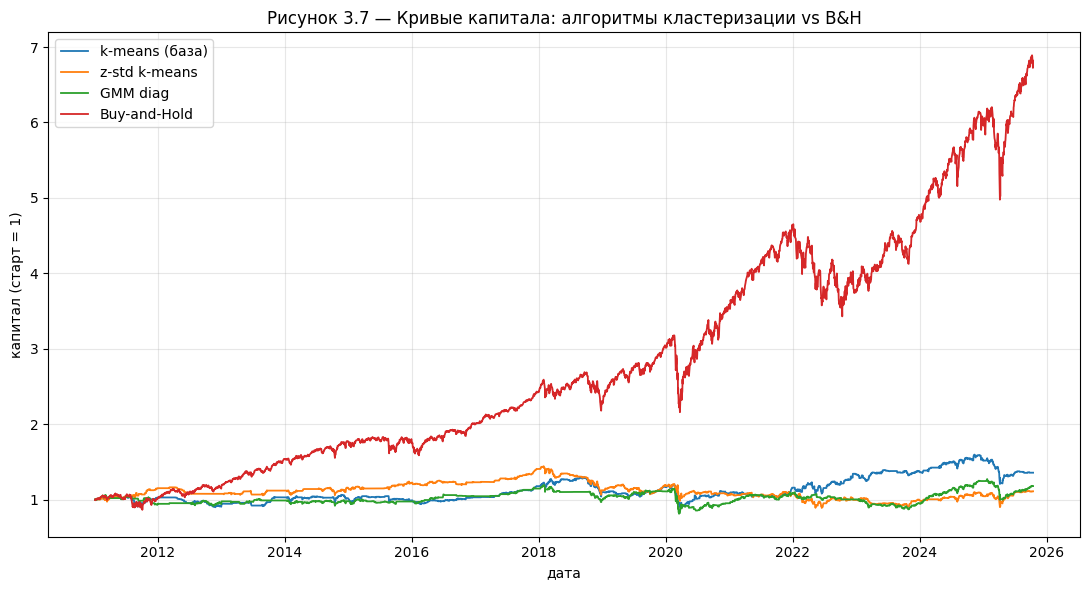

In [36]:
# страховка (оставляем)
assert isinstance(zstd_daily, np.ndarray) and len(zstd_daily) == 3717, f"zstd_daily битый: {type(zstd_daily)}"
assert isinstance(gmm_daily, np.ndarray) and len(gmm_daily) == 3717, f"gmm_daily битый: {type(gmm_daily)}"

# для базы и B&H известно точное число сделок; для альтернатив — только активные дни.
# поэтому считаем active_days для ВСЕХ (сопоставимая величина), а точные trades выносим отдельно.
variants = [
    ("k-means (база)", strat_daily, total_strat_trades, strat_exposure),
    ("z-std k-means", zstd_daily, None, np.mean(zstd_daily != 0)),
    ("GMM diag", gmm_daily, None, np.mean(gmm_daily != 0)),
    ("Buy-and-Hold", bh_daily, 1, 1.0),
]

algo_rows = []
for name, daily, ntr, expo in variants:
    mt = compute_metrics(daily, n_trades=ntr, exposure=expo, name=name)
    # active_days — число дней с ненулевой доходностью (сопоставимо между всеми вариантами)
    mt["active_days"] = int((np.asarray(daily) != 0).sum())
    # trades оставляем только там, где известно точно (база, B&H); иначе прочерк
    mt["trades"] = ntr if ntr is not None else "—"
    algo_rows.append(mt)

algo_table = pd.DataFrame(algo_rows)
# порядок колонок: метрики, потом active_days, потом точные trades
cols = ["стратегия", "Sharpe", "CAGR_%", "Vol_%", "MaxDD_%", "Calmar",
        "exposure_%", "active_days", "trades"]
algo_table = algo_table[[c for c in cols if c in algo_table.columns]]
algo_table.to_csv(TABLE_DIR / "table_3_4_algorithms.csv", index=False)
display(algo_table)

# кривые капитала всех вариантов
fig, ax = plt.subplots(figsize=(11, 6))
for name, daily, _, _ in variants:
    ax.plot(pseudo_dates, np.exp(np.cumsum(daily)), label=name, linewidth=1.3)
ax.set_ylabel("капитал (старт = 1)"); ax.set_xlabel("дата")
ax.set_title("Рисунок 3.7 — Кривые капитала: алгоритмы кластеризации vs B&H")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_3_7_algorithms.pdf", bbox_inches="tight", dpi=300)
plt.show()

**Итог. Слабость не зависит от алгоритма кластеризации.**

| вариант | Sharpe | CAGR | MaxDD | exposure |
|---|---|---|---|---|
| k-means (база) | 0.179 | 2.08% | 30.6% | 39.1% |
| z-std k-means | 0.063 | 0.70% | 38.4% | 37.3% |
| GMM diag | 0.103 | 1.12% | 32.0% | 40.2% |
| Buy-and-Hold | 0.780 | 13.90% | 32.1% | 100% |

- Все три варианта кластеризации в одном диапазоне слабости (Sharpe 0.06–0.18), все кратно проигрывают B&H. На Рис. 3.7 синяя/оранжевая/зелёная сбиты в один пучок внизу, красная (B&H) улетела.
- Замена k-means на GMM (другая форма кластеров) или z-стандартизация (другой масштаб координат) не меняют картину → ограничение в самом подходе (кластеризация delay-векторов дневных доходностей SPY), а не в выборе алгоритма.
- База (k-means) даже чуть лучше альтернатив; z-std заметно хуже (Sharpe 0.063, MaxDD вырос до 38.4%). Базовый выбор k-means оправдан.
- Оговорка: для альтернатив колонка trades не приводится (точное число сделок не сохранялось), вместо неё — active_days (дни в позиции, сопоставимая величина). На выводы по Sharpe/CAGR/MaxDD это не влияет.

Рис. 3.7 и таблицы 3.4 сохранены.

### 3.4.3 **Робастность по подпериодам**

Pseudo-OOS серия разбивается на календарные подпериоды; для каждого считаются Sharpe, CAGR, MaxDD, exposure — отдельно для стратегии и B&H. Цель — увидеть, в каких рыночных режимах стратегия хоть как-то конкурентна (ожидаемо: боковики и кризисы, не сильные тренды).

In [37]:
# границы подпериодов
periods = [
    ("2011-2014", "2011-01-01", "2014-12-31"),
    ("2015-2018", "2015-01-01", "2018-12-31"),
    ("2019-2021", "2019-01-01", "2021-12-31"),
    ("2022-2025", "2022-01-01", "2025-12-31"),
]

def metrics_subperiod(daily, dates_arr, lo, hi):
    mask = (dates_arr >= pd.Timestamp(lo)) & (dates_arr <= pd.Timestamp(hi))
    d = daily[mask]
    if len(d) < 2:
        return None
    V = np.exp(np.cumsum(d))
    T = len(d)
    sharpe = np.sqrt(252) * np.mean(d) / np.std(d, ddof=1) if np.std(d, ddof=1) > 0 else np.nan
    cagr = V[-1] ** (252 / T) - 1
    rm = np.maximum.accumulate(V)
    maxdd = ((rm - V) / rm).max()
    expo = np.mean(d != 0)
    return sharpe, cagr, maxdd, expo

rows = []
for name, lo, hi in periods:
    s = metrics_subperiod(strat_daily, pseudo_dates, lo, hi)
    b = metrics_subperiod(bh_daily, pseudo_dates, lo, hi)
    if s is None or b is None:
        continue
    rows.append({
        "период": name,
        "Sharpe_страт": round(s[0], 2), "Sharpe_BH": round(b[0], 2),
        "CAGR_страт_%": round(s[1]*100, 1), "CAGR_BH_%": round(b[1]*100, 1),
        "MaxDD_страт_%": round(s[2]*100, 1), "MaxDD_BH_%": round(b[2]*100, 1),
        "exposure_страт_%": round(s[3]*100, 0),
    })
subperiod_df = pd.DataFrame(rows)
subperiod_df.to_csv(TABLE_DIR / "table_3_4_subperiods.csv", index=False)
display(subperiod_df)

,период,Sharpe_страт,Sharpe_BH,CAGR_страт_%,CAGR_BH_%,MaxDD_страт_%,MaxDD_BH_%,exposure_страт_%
0,2011-2014,0.04,0.96,0.4,15.4,14.4,20.1,32.0
1,2015-2018,0.20,0.48,2.0,6.8,19.9,19.0,40.0
2,2019-2021,0.13,1.17,1.7,26.1,24.5,32.0,39.0
3,2022-2025,0.32,0.56,4.3,10.9,24.4,26.3,45.0


**Итог.** Стратегия проигрывает B&H во всех 4 подпериодах, но разрыв непостоянен:

| период | Sharpe страт / B&H | характер рынка |
|---|---|---|
| 2011-2014 | 0.04 / 0.96 | сильный тренд — сильное оставание |
| 2015-2018 | 0.20 / 0.48 | слабый рост — отстаёт умеренно |
| 2019-2021 | 0.13 / 1.17 | рост + V-восстановление — разгром |
| 2022-2025 | 0.32 / 0.56 | коррекция/боковик — минимальный разрыв |

Закономерность: стратегия наименее безнадёжна в 2022–2025 (волатильный боковик, инфляция, рост ставок) — там, где B&H слабее всего, стратегия подтягивается (лучший CAGR 4.3% и Sharpe 0.32). И в 2015–2018 (слабый рост) разрыв меньше, чем в трендовые 2011–2014 и 2019–2021. Подтверждает интерпретацию: метод относительно лучше работает в нетрендовых режимах (reversal эффективен в боковиках), но проигрывает в сильных трендах. exposure стабильно 32–45% во всех периодах — стратегия одинаково осторожна везде.

### 3.4.4 **Deflated Sharpe Ratio**

Итоговый Sharpe стратегии выбран как лучший из 480 конфигураций на каждом walk. DSR (раздел 2.7.4) корректирует Sharpe на число испытаний, асимметрию и эксцесс распределения доходностей. Используется дневной Sharpe, обычная (не excess) kurtosis доходностей стратегии. N_trials = 480 — число кандидатных конфигураций внутри одного walk.

DSR здесь — диагностика оптимизма отбора, а не строгая поправка на всю адаптивную процедуру (walk-forward переотбирает параметры на каждом walk).

In [38]:
from scipy import stats

def deflated_sharpe(daily, n_trials):
    """DSR по дневной серии доходностей стратегии (раздел 2.7.4)."""
    daily = np.asarray(daily, dtype=float)
    T = len(daily)
    sr = np.mean(daily) / np.std(daily, ddof=1)   # дневной Sharpe (не годовой!)
    gamma3 = stats.skew(daily)                      # асимметрия
    gamma4 = stats.kurtosis(daily, fisher=False)    # ОБЫЧНАЯ kurtosis (не excess)

    # ожидаемый максимум Sharpe при N независимых испытаниях с нулевой информативностью
    # SR0 = sqrt(Var(SR)) * [(1-gamma)*Z(1-1/N) + gamma*Z(1-1/(N*e))]
    e = np.e
    emc = 0.5772156649  # константа Эйлера-Маскерони
    z1 = stats.norm.ppf(1 - 1.0 / n_trials)
    z2 = stats.norm.ppf(1 - 1.0 / (n_trials * e))
    sr0 = (z1 * (1 - emc) + z2 * emc)               # ожидаемый макс. дневной Sharpe при H0
    # масштабируем на стандартную ошибку Sharpe
    sr0 = sr0 * np.sqrt((1 - gamma3 * sr + (gamma4 - 1) / 4 * sr**2) / (T - 1))

    # сама DSR-статистика: вероятность, что истинный SR > 0 с учётом поправок
    num = (sr - sr0) * np.sqrt(T - 1)
    den = np.sqrt(1 - gamma3 * sr + (gamma4 - 1) / 4 * sr**2)
    dsr = stats.norm.cdf(num / den)
    return dict(daily_sharpe=sr, annual_sharpe=sr*np.sqrt(252),
                skew=gamma3, kurtosis=gamma4, sr0=sr0, DSR=dsr)

dsr_res = deflated_sharpe(strat_daily, n_trials=480)
print("дневной Sharpe:", round(dsr_res["daily_sharpe"], 4))
print("годовой Sharpe:", round(dsr_res["annual_sharpe"], 3))
print("skewness:", round(dsr_res["skew"], 3))
print("kurtosis (обычная):", round(dsr_res["kurtosis"], 3))
print("порог SR0 (ожид. макс при H0):", round(dsr_res["sr0"], 4))
print("DSR:", round(dsr_res["DSR"], 4))

дневной Sharpe: 0.0113
годовой Sharpe: 0.179
skewness: -1.725
kurtosis (обычная): 30.858
порог SR0 (ожид. макс при H0): 0.0504
DSR: 0.0092


**Итог. DSR = 0.0092 — ключевой результат 3.4.**

- Дневной Sharpe 0.0113, годовой 0.179. Порог SR0 (ожидаемый максимум при H0 для 480 испытаний) = 0.0504 дневной — то есть наблюдаемый дневной Sharpe (0.0113) НИЖЕ порога, который дал бы случайный отбор лучшей из 480 конфигураций.
- DSR = 0.0092 < 0.01: после поправки на multiple testing нельзя утверждать, что истинный Sharpe положителен. Результат статистически неотличим от артефакта отбора.
- skewness = −1.725, kurtosis = 30.86 — тяжёлые левые хвосты (редкие крупные убытки, walk 36/56). DSR справедливо наказывает за этот профиль.

Честный вывод: скромная положительная доходность стратегии не выдерживает контроля на оптимизм отбора. Это сильный методологический аргумент, а не недостаток работы.

### 3.4.5 Permutation-тест (placebo)

Buy-and-Hold — не идеальный null: на бычьем рынке любая long/flat-стратегия с exposure 39% структурно отстаёт, безотносительно качества сигналов. Чтобы проверить, даёт ли кластеризация что-либо сверх случайной торговли с теми же характеристиками, строим placebo-распределение. В каждой из 1000 итераций генерируем случайную стратегию с тем же числом входов и тем же распределением длительностей удержания, что у реальной, но входы расставлены в случайные дни pseudo-OOS серии. Считаем Sharpe каждой placebo-стратегии и смотрим, попадает ли реальный Sharpe (0.179) внутрь этого распределения.

Если реальный Sharpe не выделяется на фоне случайных входов (p-value велик), это сильное свидетельство, что сигнал кластеризации не несёт информации сверх случайной рыночной экспозиции. Это прямее DSR: проверяет не оптимизм отбора, а саму информативность правила.

реальный Sharpe стратегии: 0.179
placebo Sharpe: среднее 0.073, медиана 0.072, перцентиль реального: 69%
p-value (доля placebo >= реального): 0.306


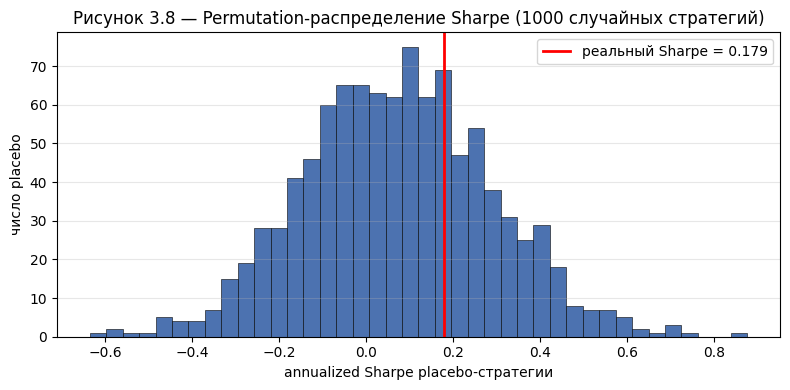

In [39]:
rng = np.random.default_rng(CONFIG["random_state"])

# реальные характеристики стратегии для воспроизведения в placebo
real_sharpe = sharpe_annual(strat_daily)
n_active_days = int((strat_daily != 0).sum())      # сколько дней стратегия в позиции
T = len(strat_daily)
c = CONFIG["cost_per_side"]

# распределение длительностей сделок берём из реальных holdout-горизонтов:
# приближённо — по выбранным h каждого walk, взвешенно по числу сделок
hold_lengths = []
for _, row in walk_df.dropna(subset=["h"]).iterrows():
    h = int(row["h"]); n_tr = int(row["n_trades_hold"])
    hold_lengths.extend([h] * n_tr)
hold_lengths = np.array(hold_lengths) if hold_lengths else np.array([1])

n_perm = 1000
perm_sharpes = np.empty(n_perm)

for i in range(n_perm):
    placebo = np.zeros(T)
    occupied = np.zeros(T, dtype=bool)
    n_trades_target = len(hold_lengths)
    placed = 0
    attempts = 0
    # расставляем случайные сделки с длительностями из реального распределения
    perm_lengths = rng.permutation(hold_lengths)
    for h in perm_lengths:
        attempts += 1
        if attempts > n_trades_target * 20:
            break
        start = rng.integers(0, T - h - 1)
        if occupied[start:start + h + 1].any():
            continue                                # не перекрываем сделки
        # доходность позиции = open-to-open SPY за период удержания
        placebo[start:start + h] += spy_daily[start:start + h]
        placebo[start] -= c                          # cost входа
        placebo[start + h - 1] -= c                  # cost выхода
        occupied[start:start + h + 1] = True
        placed += 1
    perm_sharpes[i] = sharpe_annual(placebo)

# p-value: доля placebo с Sharpe >= реального
perm_sharpes = perm_sharpes[np.isfinite(perm_sharpes)]
p_value = float(np.mean(perm_sharpes >= real_sharpe))

print(f"реальный Sharpe стратегии: {real_sharpe:.3f}")
print(f"placebo Sharpe: среднее {perm_sharpes.mean():.3f}, "
      f"медиана {np.median(perm_sharpes):.3f}, "
      f"перцентиль реального: {(perm_sharpes < real_sharpe).mean()*100:.0f}%")
print(f"p-value (доля placebo >= реального): {p_value:.3f}")

# гистограмма
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(perm_sharpes, bins=40, color="#4C72B0", edgecolor="black", linewidth=0.4)
ax.axvline(real_sharpe, color="red", linewidth=2, label=f"реальный Sharpe = {real_sharpe:.3f}")
ax.set_xlabel("annualized Sharpe placebo-стратегии")
ax.set_ylabel("число placebo")
ax.set_title("Рисунок 3.8 — Permutation-распределение Sharpe (1000 случайных стратегий)")
ax.legend()
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig_3_8_permutation.pdf", bbox_inches="tight", dpi=300)
plt.show()

**Итог. Permutation-тест — сигнал неотличим от случайной торговли.**

Реальный Sharpe стратегии = 0.179. Распределение Sharpe 1000 случайных стратегий (тот же объём торговли и те же горизонты, но входы в случайные дни): среднее 0.073, медиана 0.072. Реальный Sharpe лежит на **69-м перцентиле** placebo-распределения; **p-value = 0.306** (30.6% случайных стратегий показали Sharpe не ниже реального).

Интерпретация: реальная стратегия попадает глубоко внутрь облака случайных результатов, а не в его правый хвост (Рис. 3.8 — красная линия среди основной массы синих столбцов, не на краю). Это означает, что торговое правило на основе кластеризации **статистически неотличимо от случайной торговли** с теми же характеристиками. Если бы кластеризация несла предсказательную информацию, реальный Sharpe оказался бы в правом хвосте (перцентиль > 95, p-value < 0.05) — этого не наблюдается.

Permutation-тест отвечает на вопрос точнее, чем DSR и сравнение с Buy-and-Hold:
- сравнение с B&H показывало лишь, что long/flat-стратегия с низким exposure отстаёт на бычьем рынке (структурный эффект, не свойство сигнала);
- DSR показывал, что Sharpe не выдерживает поправки на отбор лучшей из 480 конфигураций (оптимизм отбора);
- permutation показывает, что **сам сигнал не информативен**: кластеризация не даёт ничего сверх случайного присутствия в рынке с теми же объёмом и горизонтами торговли.

Это согласованный и наиболее прямой вывод: положительная средняя доходность отдельных кластеров на train (раздел 3.2) не транслируется в торговое преимущество out-of-sample. Реальная, но слабая структура, выделяемая методом, на ликвидном SPY после costs и walk-forward проверки не несёт реализуемой предсказательной силы.

Рис. 3.8 сохранён, идёт в раздел 3.4 курсовой.

**Итоги раздела 3.4.**

Все пять проверок подтверждают: слабость основного результата (3.3) устойчива и не является артефактом одной настройки.

**Multiple testing (DSR = 0.0092).** Итоговый Sharpe выбран как лучший из 480 конфигураций на каждом walk; после поправки на это число испытаний и на тяжёлые левые хвосты (skew −1.7, kurt 30.9) деформированный Sharpe практически нулевой. Наблюдаемый дневной Sharpe (0.0113) даже ниже ожидаемого максимума при нулевой гипотезе (0.0504). Нельзя утверждать, что истинный Sharpe положителен. DSR здесь — диагностика оптимизма отбора, не строгая поправка на всю адаптивную процедуру (реальная множественность ещё выше), но при таком низком значении более строгая поправка вывод не изменит.

**Подпериоды.** Проигрыш B&H во всех четырёх интервалах, но разрыв минимален в нетрендовые периоды (2022–2025: 0.32 vs 0.56) и максимален в сильных трендах (2011–2014, 2019–2021). Метод относительно лучше в боковиках, что согласуется с reversal-природой сигнала.

**Чувствительность к параметрам.** Ни одно значение m, tau, k, h не гарантирует хорошего результата; высокие средние у редких горизонтов (h=10, h=20) — артефакт выборки в 3–6 walks, а соседние значения дают противоположный по знаку результат (m=6: −0.82 против m=7: +1.76). Маргинальная диагностика, не причинный эффект.

**Альтернативные алгоритмы.** k-means, z-std k-means и GMM дают близко слабые результаты (Sharpe 0.06–0.18), все кратно проигрывают B&H. Слабость определяется самим подходом (кластеризация delay-векторов на ликвидном ETF), а не выбором алгоритма.

**Permutation-тест (placebo).** Самая прямая проверка информативности сигнала. Реальный Sharpe (0.179) лежит на 69-м перцентиле распределения 1000 случайных стратегий с тем же объёмом торговли и теми же горизонтами (p-value = 0.306). Сигнал кластеризации статистически неотличим от случайной торговли: если бы он нёс предсказательную информацию, реальный Sharpe оказался бы в правом хвосте (p < 0.05), а не в основной массе шума. Это сильнее DSR и сравнения с B&H: показывает не оптимизм отбора и не структурный эффект низкого exposure, а отсутствие самой предсказательной силы.

**Сводно:** результат не держится ни на удачной настройке, ни на удачном алгоритме, ни на удачном периоде, не выдерживает поправки на multiple testing и неотличим от случайной торговли. Три независимых свидетельства выстраиваются в лестницу: стратегия проигрывает рынку (3.3) → Sharpe незначим после поправки на отбор (DSR) → сам сигнал не информативен (permutation). Это согласованная, методологически честная картина «метод не даёт реализуемого предсказательного преимущества», а не случайная неудача. Таблицы 3.4, Рис. 3.7 и 3.8 — в раздел 3.4 курсовой.